# Lesson 1B: Logistic Regression PyTorch Practical

<a name="introduction"></a>
## Introduction

In Lesson 1A, we explored logistic regression theory and coded from scratch a logistic regression model to classify breast cancer samples.

Now we'll implement a practical breast cancer classifier in PyTorch, one of the most popular deep learning frameworks.

This lesson focuses on implementation by:

1. Building an efficient PyTorch-based logistic regression model
2. Working with real medical data from the Wisconsin breast cancer dataset
3. Learning standard code organisation patterns
4. Establishing good practices for model development and evaluation

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [Why PyTorch for logistic regression?](#why-pytorch-for-logistic-regression)
4. [What we'll build](#what-well-build)
5. [The Wisconsin breast cancer dataset](#the-wisconsin-breast-cancer-dataset)
6. [Loading and exploring the dataset](#loading-and-exploring-the-dataset)
7. [Exploratory data analysis](#exploratory-data-analysis)
8. [Implementing a PyTorch logistic regression for cancer diagnosis](#implementing-a-pytorch-logistic-regression-for-cancer-diagnosis)
9. [How a PyTorch Logistic Regression Works](#how-a-pytorch-logistic-regression-works)
   - [The core mathematics](#the-core-mathematics)
   - [Implementation structure](#implementation-structure)
10. [The data pipeline](#the-data-pipeline)
    - [Stage 1: Data splitting](#stage-1-data-splitting)
    - [Stage 2: Feature standardisation](#stage-2-feature-standardisation)
    - [Stage 3: PyTorch dataset creation](#stage-3-pytorch-dataset-creation)
    - [What's a Tensor?](#whats-a-tensor)
    - [Stage 4: Data Loading and batch processing](#stage-4-data-loading-and-batch-processing)
11. [The CancerClassifier: From mathematical principles to PyTorch implementation](#the-cancerclassifier-from-mathematical-principles-to-pytorch-implementation)
    - [The mathematical foundation](#the-mathematical-foundation)
    - [Understanding nn.Module](#understanding-nnmodule)
    - [The linear layer: Modern matrix operations](#the-linear-layer-modern-matrix-operations)
    - [Weight initialisation: Xavier initialisation](#weight-initialisation-xavier-initialisation)
    - [The Forward Pass: Computing cancer probability](#the-forward-pass-computing-cancer-probability)
    - [The prediction method: Making clinical decisions](#the-prediction-method-making-clinical-decisions)
    - [End-to-End example: A single cell's journey](#end-to-end-example-a-single-cells-journey)
12. [Understanding training: How models learn from data](#understanding-training-how-models-learn-from-data)
    - [Full batch gradient descent](#full-batch-gradient-descent)
    - [Mini-batch gradient descent](#mini-batch-gradient-descent)
    - [Stochastic gradient descent](#stochastic-gradient-descent)
    - [Why we use mini-batches with validation](#why-we-use-mini-batches-with-validation)
    - [Understanding the Adam optimiser](#understanding-the-adam-optimiser)
13. [Understanding the training process](#understanding-the-training-process)
    - [Function signature and inputs](#function-signature-and-inputs)
    - [Setup phase](#setup-phase)
    - [Training phase](#training-phase)
    - [Validation phase and early stopping](#validation-phase-and-early-stopping)
    - [Final evaluation](#final-evaluation)
    - [Monitoring training progress](#monitoring-training-progress)
14. [Understanding learning dynamics](#understanding-learning-dynamics)
15. [Model hyperparameter optimisation](#model-hyperparameter-optimisation)
16. [Model evaluation implementation](#model-evaluation)
17. [How to evaluate a classification model](#how-to-evaluate-a-classification-model)
    - [Basic classification terms](#basic-classification-terms)
    - [Core performance metrics](#core-performance-metrics)
    - [Understanding the visualisations](#understanding-the-visualisations)
    - [Key insights](#key-insights)
    - [Evaluation best practices](#evaluation-best-practices)
18. [Persisting and loading our model](#persisting-and-loading-our-model)
19. [Looking Forward: From Logistic Regression to Neural Networks](#looking-forward-from-logistic-regression-to-neural-networks)
20. [Conclusion](#conclusion)
    - [Looking ahead to lesson 2: Decision Trees](#looking-ahead-to-lesson-2-decision-trees)
    - [Further Reading](#further-reading)

<a name="required-libraries"></a>
## Required Libraries

In this lesson we will use the following libraries:

| Library | Purpose |
|---------|---------|
| NumPy | Numerical computing and array operations |
| Pandas | Data tables and data manipulation |
| PyTorch | Deep learning framework |
| Matplotlib | Graph plotting functions |
| Seaborn | Statistical visualisation built on top of Matplotlib |
| Scikit-learn | Machine learning utilities: dataset loading, train/test splitting, preprocessing, metrics |
| System Utilities | Logging, file ops, typing, hashing, datetime |


In [1]:
# System utilities, logging, hashing, typing etc.
from typing import List, Optional, Union, Tuple, Dict, Any
import json
import logging
import hashlib
import os
from datetime import datetime
from pathlib import Path

# Third party imports - core data science
import numpy as np
import pandas as pd
from numpy.typing import NDArray

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, auc
)

# Environment configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Jupyter and visualisation settings
%matplotlib inline
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Logging configuration
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

print("Libraries imported and configured successfully!")

Using device: cpu
Libraries imported and configured successfully!


<a name="why-pytorch-for-logistic-regression"></a>

This notebook fits the same model Lesson 1A derives from first principles -- $\hat y = \sigma(w^\top x + b)$ -- but through PyTorch's `nn.Module`, autograd and optimiser machinery rather than a hand-written gradient loop. The loss PyTorch minimises is the same binary cross-entropy 1A uses:

$J(w,b) = -\dfrac{1}{m}\sum_{i=1}^m \left[y_i \log \hat y_i + (1-y_i)\log(1-\hat y_i)\right]$

and its gradient with respect to the weights has the same clean form the sigmoid-plus-cross-entropy pairing always produces (Lesson 3A derives the general case):

$\nabla_w J = \dfrac{1}{m} X^\top (\hat y - y), \qquad \dfrac{\partial J}{\partial b} = \dfrac{1}{m}\sum_{i=1}^m (\hat y_i - y_i)$

`loss.backward()` computes exactly this gradient via autograd; PyTorch's contribution here is not a different objective, it is not having to derive and hand-code that gradient.
## Why PyTorch for logistic regression?

While we built logistic regression from scratch in Lesson 1A, PyTorch offers several key advantages:

1. **Efficient computation**
   - Automatic differentiation
   - GPU acceleration when available
   - Optimised numerical operations

2. **Production-ready tools**
   - Built-in data loading utilities
   - Memory-efficient batch processing
   - Robust optimisation algorithms

3. **Reusable patterns**
   - Model organisation with `nn.Module`
   - Data handling with `Dataset` and `DataLoader`
   - Training loops and evaluation workflows

These fundamentals will serve us well throughout our machine learning journey, particularly when we move on to neural networks (Lesson 3), as our PyTorch logistic regression implementation is technically a single-layer neural network.

<a name="what-well-build"></a>
## What we'll build

First, we'll perform exploratory data analysis to understand our dataset and make informed processing decisions.

Then, we'll:

1. Implement a PyTorch-based logistic regression model for breast cancer classification

2. Review our implementation in detail to understand:
    
    2.1. The data pipeline
    - Data preparation and standardisation
    - Converting to PyTorch tensors
    - Efficient batch loading
    
    2.2. The model architecture
    - Building on nn.Module
    - Linear layer and weight initialisation
    - Forward pass and prediction interface
    
    2.3. The training process
    - Different gradient descent approaches (full-batch, mini-batch, stochastic)
    - Training optimisation with Adam optimiser
    - Early stopping and hyperparameter tuning
    - Inside the training loop
    - Validation and performance monitoring

3. Evaluate our model's performance:
    - Medical metrics and error analysis
    - Model persistence and production considerations

By the end of this lesson, you'll have both a working cancer classifier and practical experience with professional PyTorch development - skills that form the foundation for more advanced deep learning projects.

Let's begin by getting an understanding of the dataset we'll be working with.

<a name="the-wisconsin-breast-cancer-dataset"></a>
## The Wisconsin breast cancer dataset

When doctors examine breast tissue samples under a microscope, they look for specific cellular characteristics that might indicate cancer:

1. **Cell Size and Shape**
   - Radius (mean distance from center to perimeter)
   - Perimeter (size of the outer boundary)
   - Area (total space occupied by the cell)
   - Cancer cells often appear larger and more irregular

2. **Texture Analysis**
   - Surface variations and patterns
   - Standard deviation of gray-scale values
   - Malignant cells typically show more variation

3. **Cell Boundaries**
   - Compactness (perimeter² / area)
   - Concavity (severity of concave portions)
   - Cancer cells often have irregular, ragged boundaries

### Dataset Structure

The dataset contains 569 samples with confirmed diagnoses. For each biopsy sample, we have:
- 30 numeric features capturing the aforementioned cell characteristics
- Binary classification: Malignant (1) or Benign (0)

This presents an ideal scenario for logistic regression because:
1. Clear binary outcome (malignant vs benign)
2. Numeric features that can be combined linearly
3. Well-documented medical relationships
4. Real-world impact of predictions

Our task mirrors a real diagnostic challenge: Can we use these cellular measurements to predict whether a tumor is cancerous?

This is exactly the kind of high-stakes binary classification problem where logistic regression's interpretable predictions become crucial - doctors need to understand not just what the model predicts, but how confident it is in that prediction.

<a name="loading-and-exploring-the-dataset"></a>
## Loading and exploring the dataset

Let's explore the Wisconsin Breast Cancer dataset through a series of visualisations and analyses to understand our data better.

Let's start by:

   1. Getting a basic overview of our dataset
      - Look at the first few rows of each feature in a table format
      - Check how many samples and features we have
      - Display summary statistics for each feature (mean, std, min, max, skewness, kurtosis)
      
   2. Investigating the distribution of our features
      - Generate box plots for each feature to compare measurements between cancerous and non-cancerous cases
      - Generate histograms with kernel density estimation overlays to visualise each feature's distribution

   3. Investigating relationships between features
      - Create three sets of paired plots for the most distinct pairs
      - Create three sets of paired plots for the least distinct pairs
      - Create three sets of paired plots for moderately distinct pairs

   4. Examining correlations
      - Analyse how each feature correlates with the diagnosis of cancer
      - Investigate how features correlate with one another
      - Utilise these findings to guide our selection of features


=== Dataset Overview ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Shape: (569, 31)

=== Summary Statistics ===


,mean,std,min,max,skew,kurtosis
mean radius,14.127,3.524,6.981,28.110,0.942,0.846
mean texture,19.290,4.301,9.710,39.280,0.650,0.758
mean perimeter,91.969,24.299,43.790,188.500,0.991,0.972
mean area,654.889,351.914,143.500,2501.000,1.646,3.652
mean smoothness,0.096,0.014,0.053,0.163,0.456,0.856
mean compactness,0.104,0.053,0.019,0.345,1.190,1.650
mean concavity,0.089,0.080,0.000,0.427,1.401,1.999
mean concave points,0.049,0.039,0.000,0.201,1.171,1.067
mean symmetry,0.181,0.027,0.106,0.304,0.726,1.288
mean fractal dimension,0.063,0.007,0.050,0.097,1.304,3.006


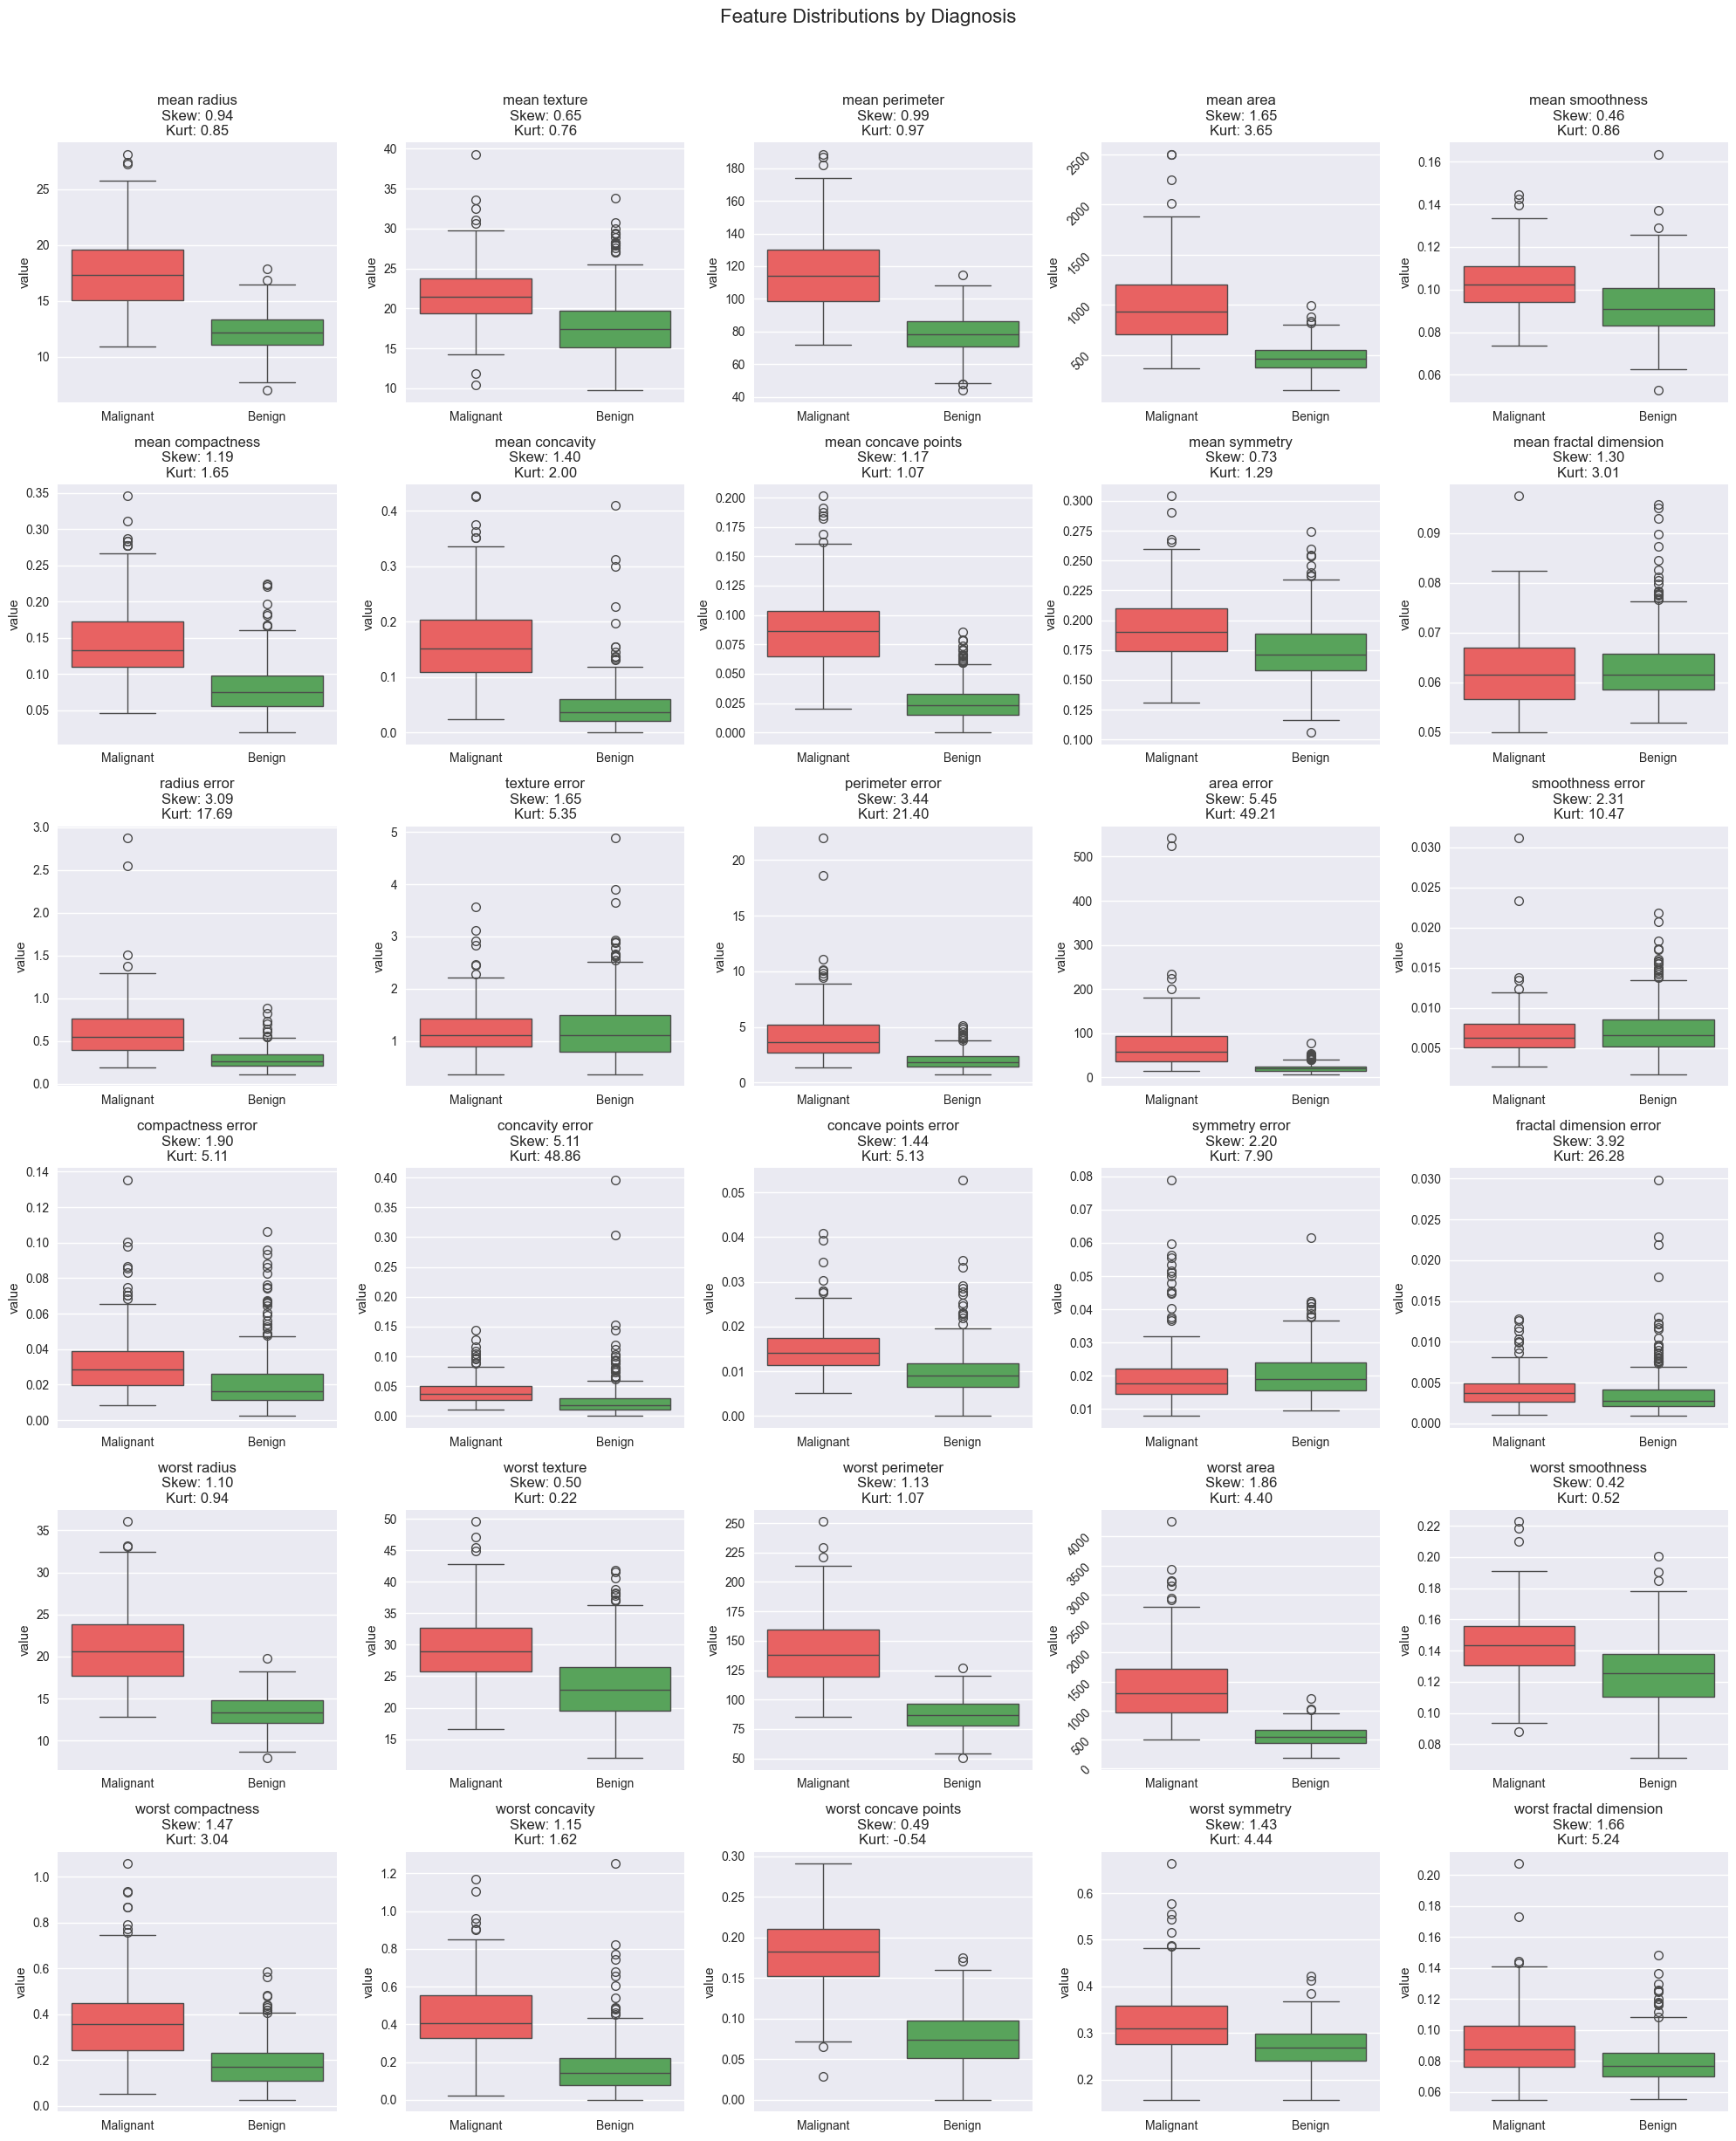

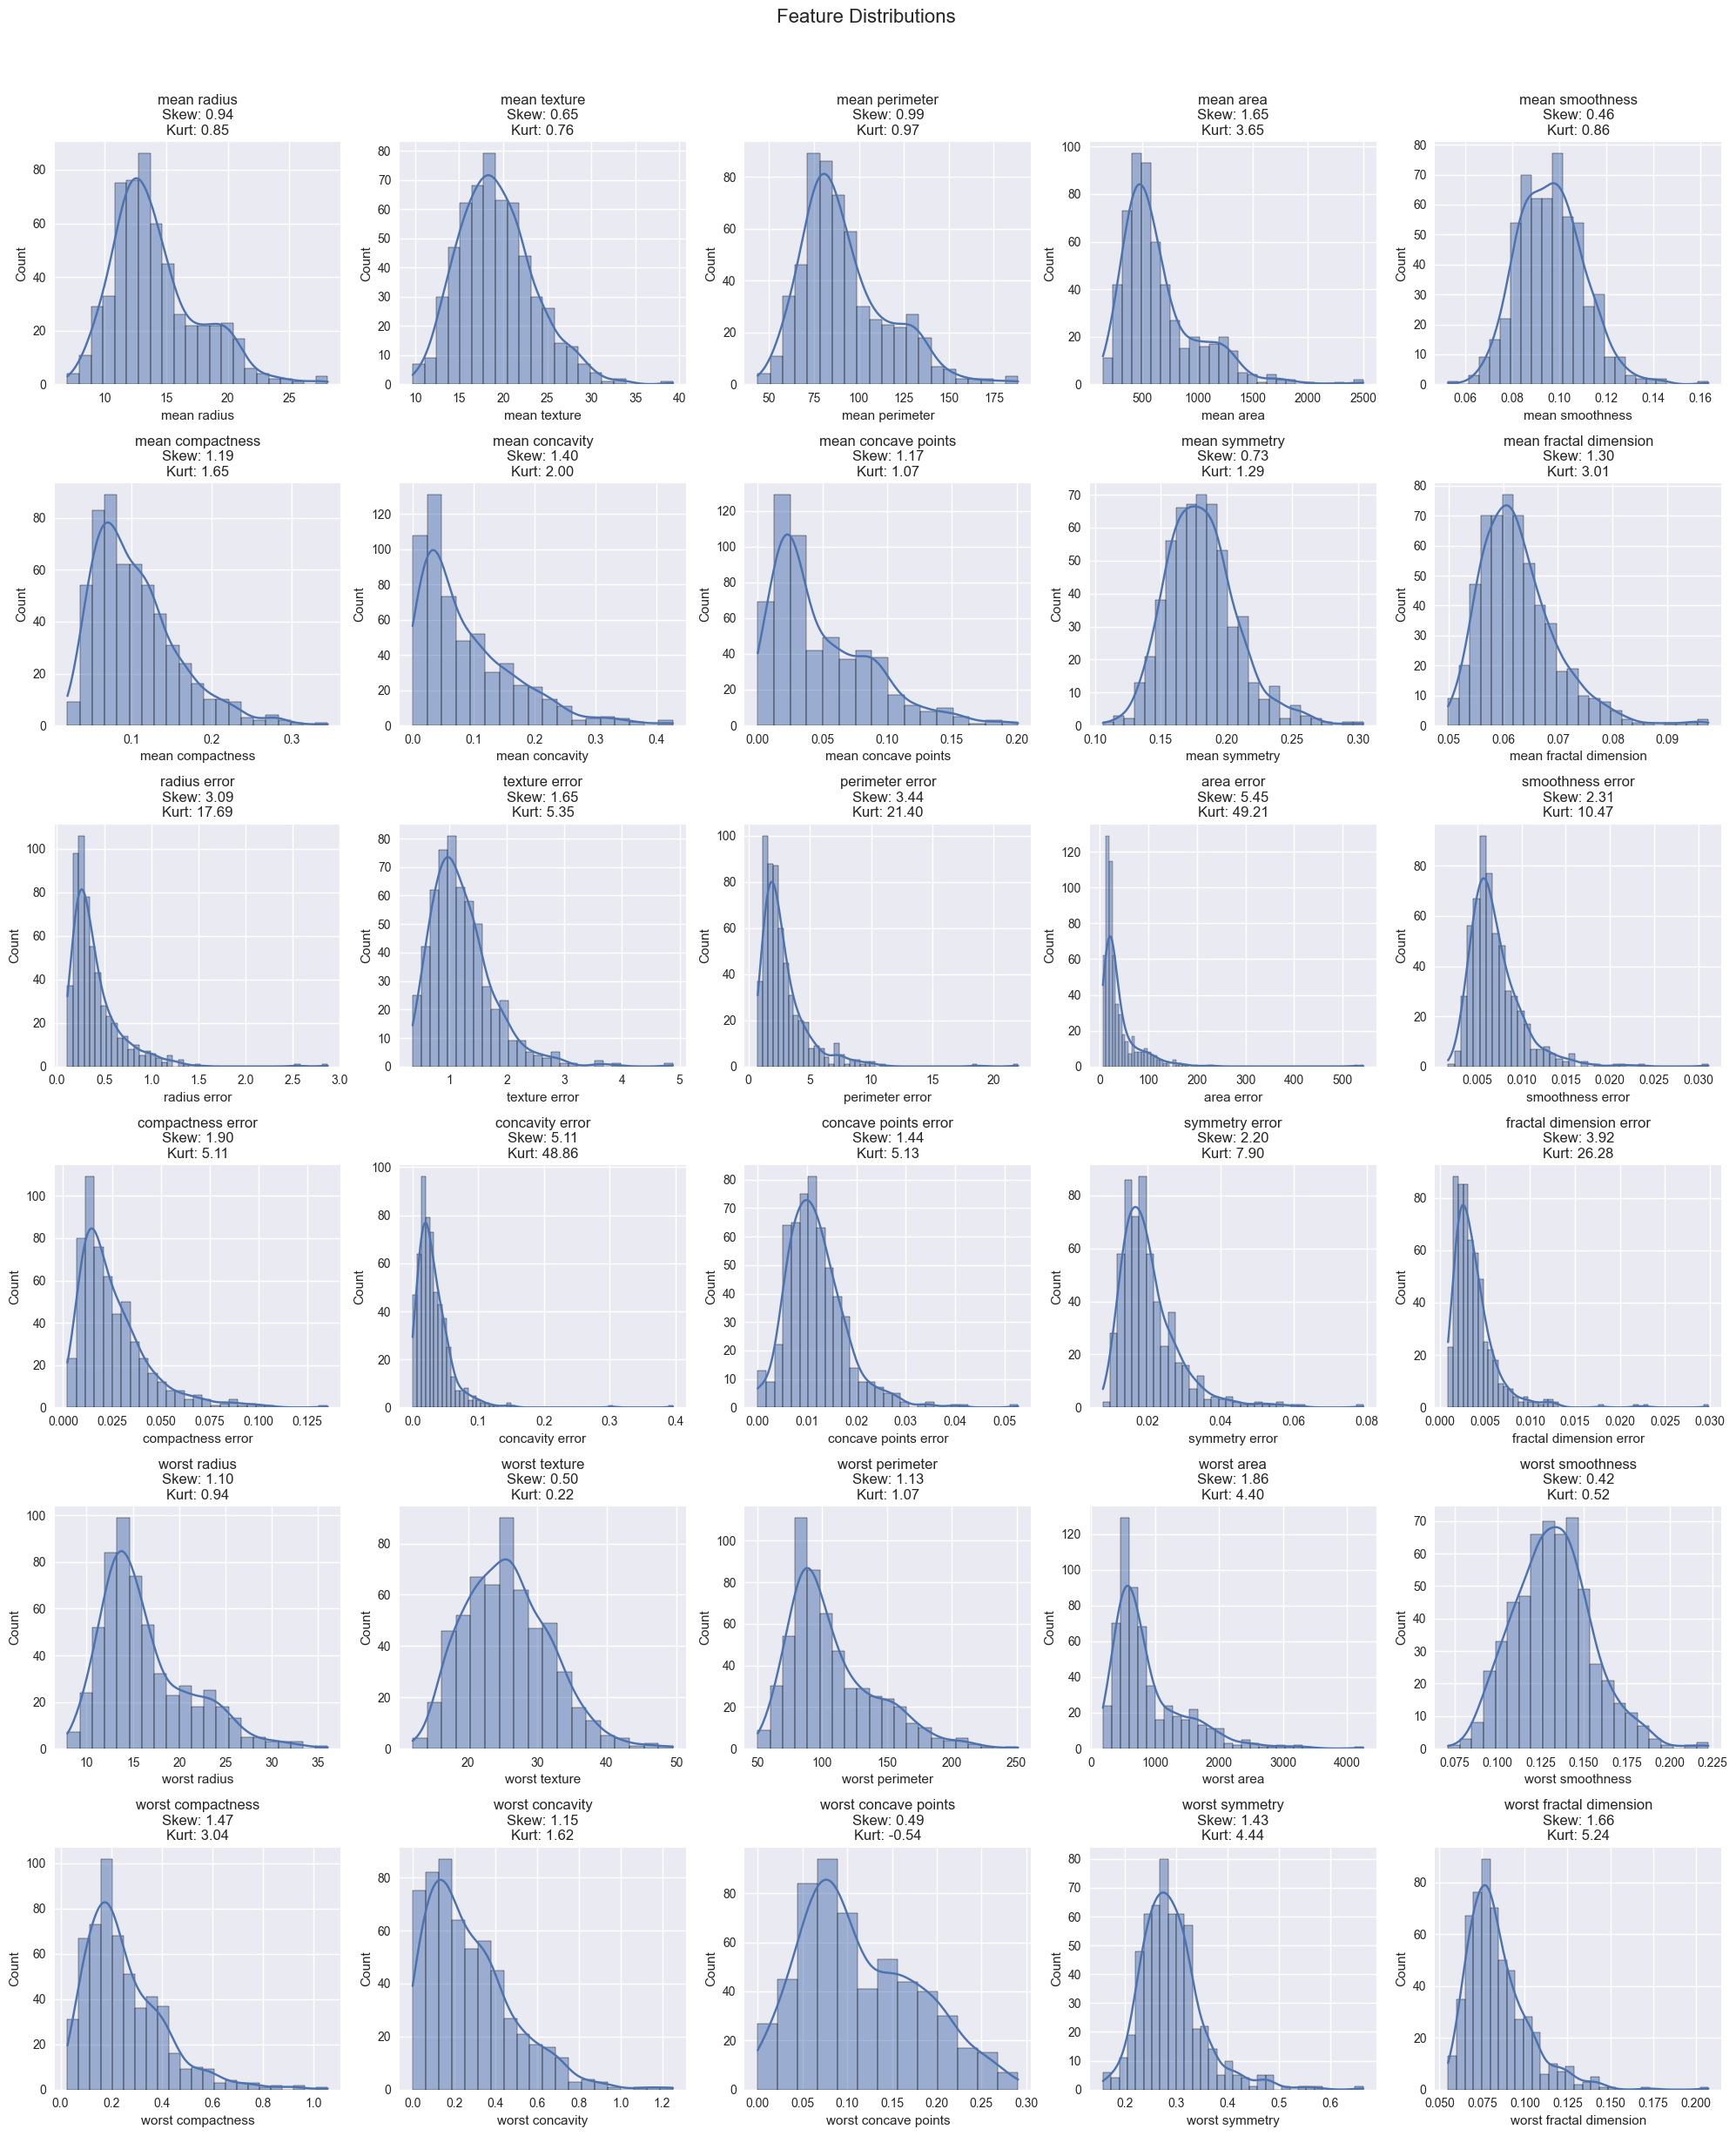

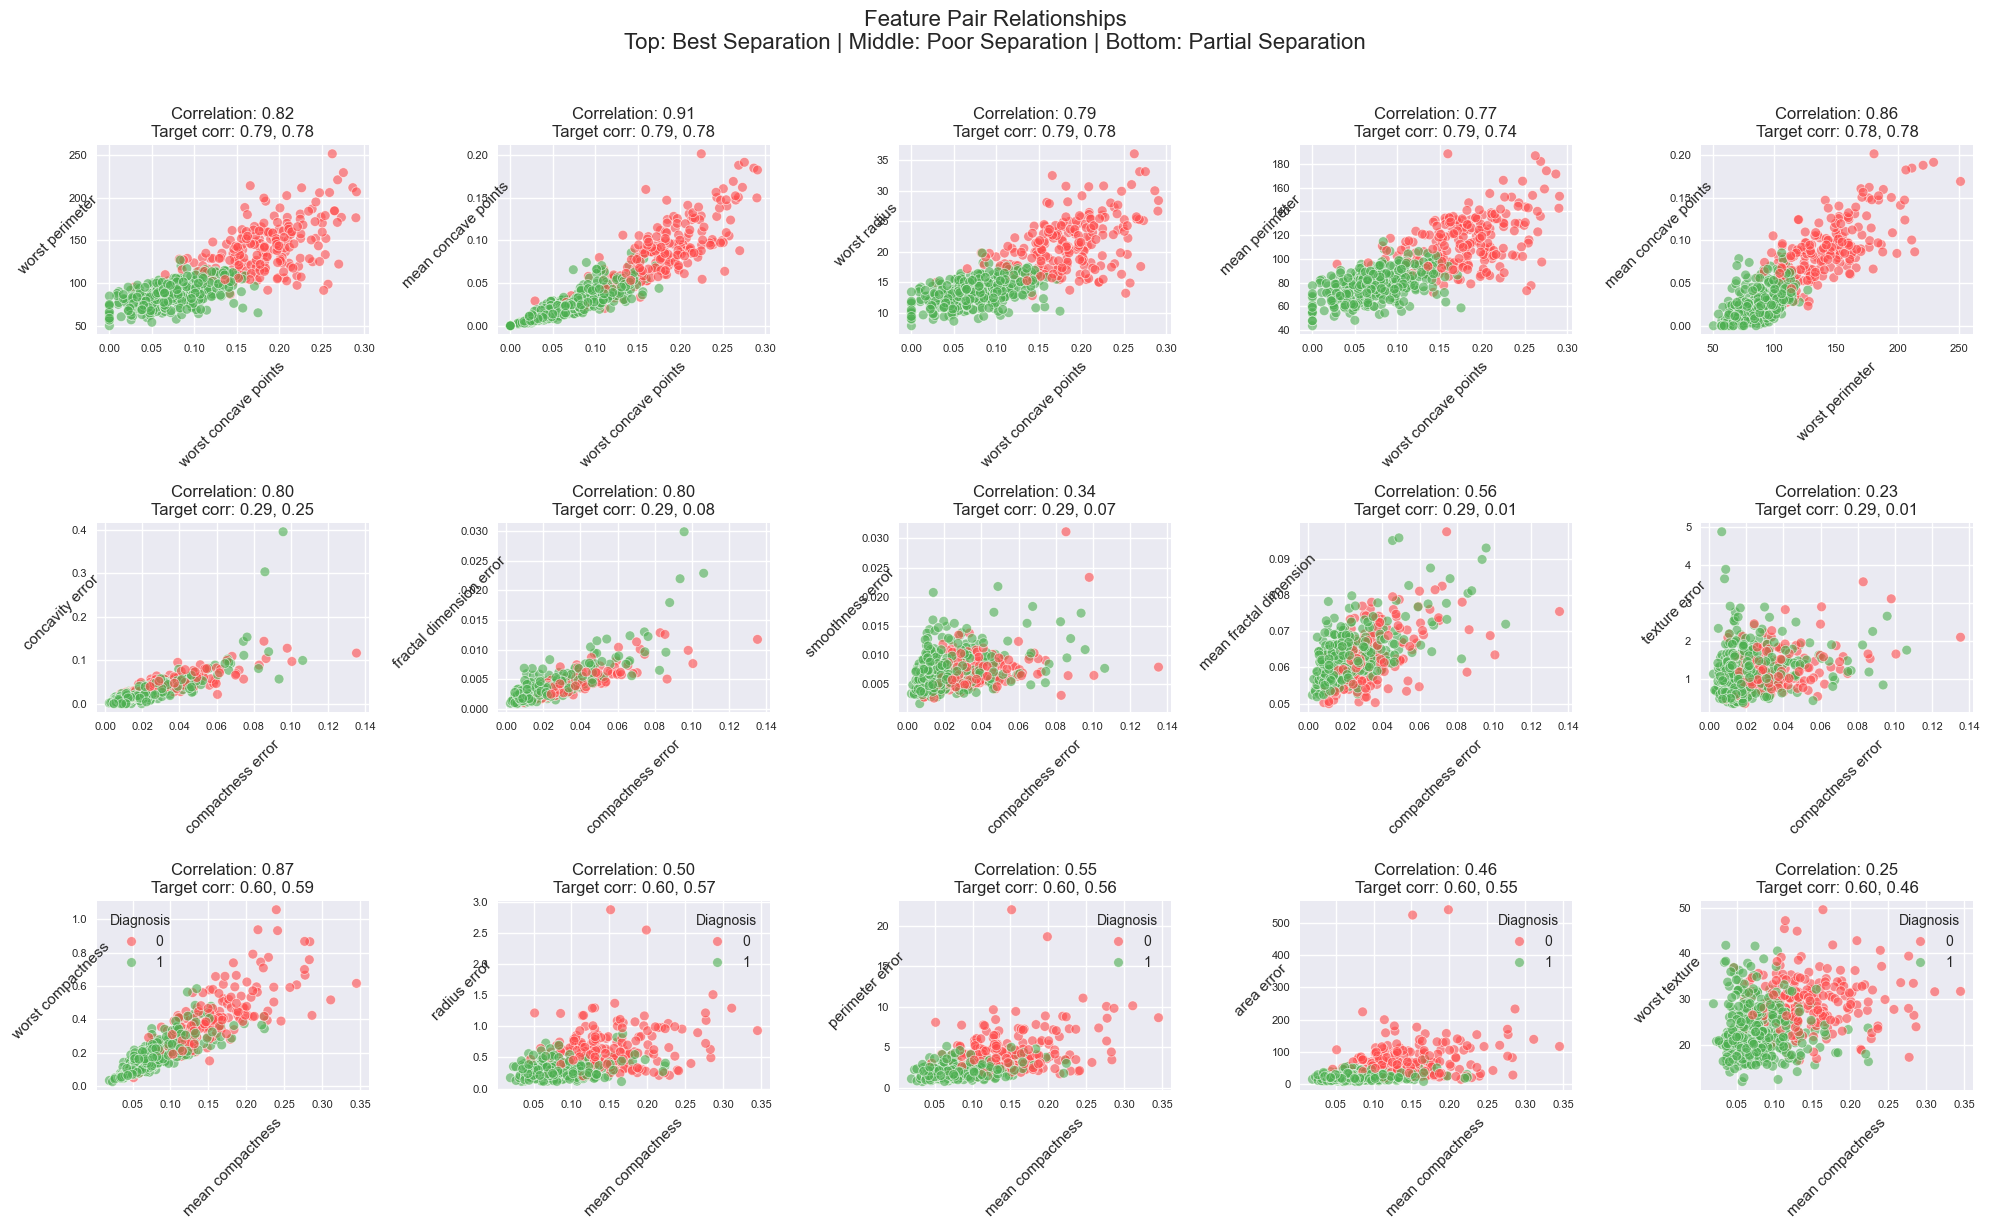

In [2]:
def load_cancer_data():
   """Load and prepare breast cancer dataset."""
   cancer = load_breast_cancer()
   df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
   df['target'] = cancer.target
   return df

def plot_initial_analysis(df):
   """Plot comprehensive initial data analysis including skewness and kurtosis."""
   # Print basic information
   print("=== Dataset Overview ===")
   display(df.head())
   print(f"\nShape: {df.shape}")

   print("\n=== Summary Statistics ===")
   stats = pd.DataFrame({
       'mean': df.mean(),
       'std': df.std(),
       'min': df.min(),
       'max': df.max(),
       'skew': df.skew(),
       'kurtosis': df.kurtosis()
   }).round(3)
   display(stats)

   # Box plots for each feature by diagnosis
   n_features = len(df.columns) - 1  # Excluding target column
   n_rows = (n_features + 4) // 5

   fig, axes = plt.subplots(n_rows, 5, figsize=(20, 4*n_rows))
   axes = axes.ravel()

   tumor_colors = {1: '#4CAF50', 0: '#FF4B4B'}

   for idx, feature in enumerate(df.columns[:-1]):
       plot_df = pd.DataFrame({
           'value': df[feature],
           'diagnosis': df['target'].map({0: 'Malignant', 1: 'Benign'})
       })

       sns.boxplot(data=plot_df, x='diagnosis', y='value',
                  hue='diagnosis', palette=[tumor_colors[0], tumor_colors[1]],
                  legend=False, ax=axes[idx])
       axes[idx].set_title(f'{feature}\nSkew: {df[feature].skew():.2f}\nKurt: {df[feature].kurtosis():.2f}')
       axes[idx].set_xlabel('')

       if max(plot_df['value']) > 1000:
           axes[idx].tick_params(axis='y', rotation=45)

   for idx in range(n_features, len(axes)):
       axes[idx].set_visible(False)

   plt.suptitle('Feature Distributions by Diagnosis', y=1.02, size=16)
   plt.tight_layout()
   plt.show()

   # Distribution plots (5 per row)
   n_rows = (n_features + 4) // 5
   fig, axes = plt.subplots(n_rows, 5, figsize=(20, 4*n_rows))
   axes = axes.ravel()

   for idx, feature in enumerate(df.columns[:-1]):
       sns.histplot(df[feature], ax=axes[idx], kde=True)
       axes[idx].set_title(f'{feature}\nSkew: {df[feature].skew():.2f}\nKurt: {df[feature].kurtosis():.2f}')

   for idx in range(n_features, len(axes)):
       axes[idx].set_visible(False)

   plt.suptitle('Feature Distributions', y=1.02, size=16)
   plt.tight_layout()
   plt.show()

def plot_feature_pairs(df):
    """Plot selected informative feature pairs in a 3x3 or 3x5 grid."""
    # Get feature correlations with target
    target_corr = df.corr()['target'].abs().sort_values(ascending=False)

    # Get feature pair correlations
    corr_matrix = df.iloc[:, :-1].corr().abs()

    # 1. Top 5 most separating pairs (highest correlation with target)
    top_features = target_corr[1:6].index
    top_pairs = [(f1, f2) for i, f1 in enumerate(top_features)
                 for j, f2 in enumerate(top_features[i+1:], i+1)][:5]

    # 2. 5 pairs with minimal separation
    # Get features with low target correlation
    low_corr_features = target_corr[target_corr < 0.3].index
    low_sep_pairs = [(f1, f2) for i, f1 in enumerate(low_corr_features)
                     for j, f2 in enumerate(low_corr_features[i+1:], i+1)][:5]

    # 3. 5 interesting pairs showing partial separation
    # Features with moderate target correlation
    mod_corr_features = target_corr[(target_corr >= 0.3) & (target_corr < 0.6)].index
    mod_sep_pairs = [(f1, f2) for i, f1 in enumerate(mod_corr_features)
                     for j, f2 in enumerate(mod_corr_features[i+1:], i+1)][:5]

    # Combine all pairs
    all_pairs = top_pairs + low_sep_pairs + mod_sep_pairs

    # Plot pairs
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    axes = axes.ravel()

    tumor_colors = {1: '#4CAF50', 0: '#FF4B4B'}

    for idx, (feat1, feat2) in enumerate(all_pairs):
        sns.scatterplot(data=df, x=feat1, y=feat2, hue='target',
                       palette=tumor_colors, ax=axes[idx], alpha=0.6)
        corr_val = corr_matrix.loc[feat1, feat2]
        target_corr1 = target_corr[feat1]
        target_corr2 = target_corr[feat2]

        title = f'Correlation: {corr_val:.2f}\nTarget corr: {target_corr1:.2f}, {target_corr2:.2f}'
        axes[idx].set_title(title)
        axes[idx].set_xlabel(feat1, rotation=45)
        axes[idx].set_ylabel(feat2, rotation=45)
        axes[idx].tick_params(axis='both', labelsize=8)
        if idx >= 10:  # Only show legend on last row
            axes[idx].legend(title='Diagnosis')
        else:
            axes[idx].legend().remove()

    plt.suptitle('Feature Pair Relationships\nTop: Best Separation | Middle: Poor Separation | Bottom: Partial Separation',
                y=1.02, size=16)
    plt.tight_layout()
    plt.show()

# Execute analysis
df = load_cancer_data()
plot_initial_analysis(df)
plot_feature_pairs(df)

<a name="exploratory-data-analysis"></a>
## Exploratory data analysis

Our data summary, exploration and visualisations above highlight several key characteristics of our Wisconsin Breast Cancer dataset.

Let's analyse what we've discovered to both understand the characteristics of our data and how we'll handle them with widely-used machine learning frameworks like PyTorch and Scikit-learn.

### Dataset overview

The dataset contains 569 breast tissue biopsies with confirmed diagnoses:
```python
# Class distribution
Benign:    357 (62.7%)  # Non-cancerous samples
Malignant: 212 (37.3%)  # Cancerous samples
```

Each biopsy sample contains 30 measurements that capture cell characteristics.

These measurements provide a comprehensive view of cellular features that may indicate malignancy.

For proper model evaluation, we'll split this data into three sets:
```python
# Three-way split for robust evaluation
Training:    364 samples (64%)  # Learning patterns
Validation:   91 samples (16%)  # Tuning decisions
Test:        114 samples (20%)  # Final evaluation
```

This split ensures:
1. Sufficient training data to learn patterns
2. Independent validation set for early stopping
3. Held-out test set matching Lesson 1A's size

### Key data characteristics

1. **Feature scale variations**
   ```python
   # Primary measurements show wide scale differences
   radius:     14.127 ± 3.524   # Base cell measurements
   area:      654.889 ± 351.914 # Derived measurements
   smoothness:  0.096 ± 0.014   # Texture measurements
   
   # Range spans multiple orders of magnitude
   area:        143.5 - 2501.0  
   radius:        6.9 - 28.1    
   smoothness:    0.05 - 0.16   
   ```

The features in our dataset span several orders of magnitude, from microscopic texture measurements to larger area calculations. This variation in scale is typical in medical data where we measure different aspects of the same sample. Importantly, our standardisation will be based only on training set statistics to prevent information leakage.

2. **Distribution patterns**
   ```python
   # Feature distributions by skewness
   Normal:       smoothness (0.46), texture (0.50)  # Linear relationships
   Right-skewed: radius (0.94), area (1.65)         # Size features
   Heavy-tailed: perimeter error (3.44)             # Diagnostic signals
   
   # Error terms show important variations
   perimeter error: 2.866 ± 2.022  # Outliers indicate malignancy
   area error:     40.337 ± 45.491 # Keep these variations
   ```

Our features show varying distribution patterns. Some measurements like smoothness follow normal distributions, while others, particularly size-related features, show right-skewed patterns. The error terms exhibit heavy-tailed distributions, which often carry important diagnostic information. These patterns remain consistent across our three data splits, indicating good stratification.

3. **Feature-target relationships**
   ```python
   # Strong linear correlations with diagnosis
   worst concave points: -0.794  # Key diagnostic feature
   worst perimeter:      -0.783  # Size indicator
   mean concave points:  -0.777  # Shape characteristic
   
   # Multiple strong predictors
   Top 5 features: r = -0.794 to -0.743  # Linear model suitable
   ```

Several features show strong correlations with the diagnosis, particularly measurements related to cell shape and size. These strong linear relationships support our choice of logistic regression as a modelling approach. The correlations maintain similar strengths across our three data splits, suggesting reliable generalisation.

### From manual to standard implementation

In Lesson 1A, we wrote manual implementations to understand the mathematics. Now we'll use PyTorch and Scikit-learn to provide the same functionality while adding proper validation:

1. **Data processing**
   ```python
   # Feature standardisation
   # Lesson 1A: Manual implementation
   def standardise_features(X):
       mean = np.mean(X, axis=0)
       std = np.std(X, axis=0)
       return (X - mean) / std

   # Lesson 1B: Standard with validation
   from sklearn.preprocessing import StandardScaler
   scaler = StandardScaler()
   training_features_scaled = scaler.fit_transform(training_features)
   validation_features_scaled = scaler.transform(validation_features)
   test_features_scaled = scaler.transform(test_features)

   # Dataset creation
   # Lesson 1A: Simple numpy arrays
   X_train, y_train = training_features, training_labels

   # Lesson 1B: PyTorch datasets and dataloaders
   training_dataset = CancerDataset(training_features_scaled, training_labels)
   validation_dataset = CancerDataset(validation_features_scaled, validation_labels)
   test_dataset = CancerDataset(test_features_scaled, test_labels)

   training_loader = DataLoader(training_dataset, batch_size=32, shuffle=True)
   validation_loader = DataLoader(validation_dataset, batch_size=32)
   test_loader = DataLoader(test_dataset, batch_size=32)
   ```

2. **Model implementation**
   ```python
   # Lesson 1A: Manual implementation
   class SimpleLogisticRegression:
       def __init__(self, num_features):
           self.weights = np.zeros(num_features)
           self.bias = 0
           
       def calculate_linear_scores(self, X):
           return np.dot(X, self.weights) + self.bias
           
       def sigmoid(self, scores):
           return 1 / (1 + np.exp(-scores))

   # Lesson 1B: PyTorch implementation
   class CancerClassifier(nn.Module):
       def __init__(self, input_features):
           super().__init__()
           self.linear = nn.Linear(input_features, 1)
           self.sigmoid = nn.Sigmoid()
           
           # Proper weight initialisation using Xavier/Glorot
           nn.init.xavier_uniform_(self.linear.weight)
           nn.init.zeros_(self.linear.bias)
           
       def forward(self, x):
           # Step 1: Compute weighted sum (z = wx + b)
           z = self.linear(x)
           # Step 2: Convert to probability using sigmoid
           p = self.sigmoid(z)
           return p
           
       def predict(self, x):
           # Disable gradient tracking for efficiency
           with torch.no_grad():
               probabilities = self(x)
               # Default threshold of 0.5
               return (probabilities > 0.5).float()
   ```

3. **Training process**
   ```python
   # Lesson 1A: Manual implementation
   def train_model(self, X, y, learning_rate, epochs):
       for epoch in range(epochs):
           scores = self.calculate_linear_scores(X)
           probs = self.sigmoid(scores)
           loss = self.calculate_loss(y, probs)
           gradients = self.calculate_gradients(X, y, probs)
           self.weights -= learning_rate * gradients

   # Lesson 1B: PyTorch implementation with early stopping
   def train_model(model, training_loader, validation_loader, test_loader,
                  epochs=1000, lr=0.001, patience=5):
       criterion = nn.BCELoss()
       optimiser = optim.Adam(model.parameters(), lr=lr)
       
       best_val_loss = float('inf')
       best_weights = None
       no_improve = 0
       
       for epoch in range(epochs):
           # Training phase
           model.train()
           for features_batch, labels_batch in training_loader:
               predictions = model(features_batch)
               loss = criterion(predictions, labels_batch)
               
               optimiser.zero_grad()
               loss.backward()
               optimiser.step()
           
           # Validation phase
           model.eval()
           with torch.no_grad():
               val_loss = validate_epoch(model, validation_loader, criterion)
               
           # Early stopping check
           if val_loss < best_val_loss:
               best_val_loss = val_loss
               best_weights = model.state_dict().copy()
               no_improve = 0
           else:
               no_improve += 1
               if no_improve == patience:
                   print(f'Early stopping at epoch {epoch+1}')
                   break
       
       # Restore best weights
       model.load_state_dict(best_weights)
       return model
   ```

### Next steps

Going forward we'll implement a PyTorch logistic regression model that properly separates concerns and follows standard:

1. **Enhanced data pipeline**
   - Implements proper three-way data splitting with stratification
   - Uses StandardScaler for robust feature scaling
   - Leverages PyTorch's DataLoader for efficient batch processing
   - Maintains data integrity across all splits

2. **Modernised model architecture**
   - Utilises PyTorch's Module system for clean implementation
   - Implements proper weight initialisation
   - Separates prediction logic from training
   - Provides clear interfaces for training and inference

3. **Robust training process**
   - Implements mini-batch processing for efficiency
   - Uses Adam optimiser for adaptive learning rates
   - Incorporates validation-based early stopping
   - Maintains proper separation of training, validation and test sets


<a name="implementing-a-pytorch-logistic-regression-for-cancer-diagnosis"></a>
## Implementing a PyTorch logistic regression for cancer diagnosis

Building on our theoretical understanding from Lesson 1A, let's implement a logistic regression model using PyTorch.

This modern implementation introduces several powerful features and optimisations while maintaining the same core mathematical principles we learned previously.

Epoch 10/1000
Training Loss: 0.5959, Accuracy: 0.7060
Validation Loss: 0.5664, Accuracy: 0.7802

Epoch 20/1000
Training Loss: 0.3451, Accuracy: 0.9286
Validation Loss: 0.3411, Accuracy: 0.9231

Epoch 30/1000
Training Loss: 0.2633, Accuracy: 0.9451
Validation Loss: 0.2528, Accuracy: 0.9670

Epoch 40/1000
Training Loss: 0.2088, Accuracy: 0.9588
Validation Loss: 0.2067, Accuracy: 0.9670



Epoch 50/1000
Training Loss: 0.1728, Accuracy: 0.9643
Validation Loss: 0.1781, Accuracy: 0.9670

Epoch 60/1000
Training Loss: 0.1508, Accuracy: 0.9670
Validation Loss: 0.1585, Accuracy: 0.9670

Epoch 70/1000
Training Loss: 0.1371, Accuracy: 0.9725
Validation Loss: 0.1443, Accuracy: 0.9670

Epoch 80/1000
Training Loss: 0.1237, Accuracy: 0.9725
Validation Loss: 0.1335, Accuracy: 0.9780



Epoch 90/1000
Training Loss: 0.1168, Accuracy: 0.9725
Validation Loss: 0.1247, Accuracy: 0.9780

Epoch 100/1000
Training Loss: 0.1083, Accuracy: 0.9725
Validation Loss: 0.1176, Accuracy: 0.9780

Epoch 110/1000
Training Loss: 0.1052, Accuracy: 0.9725
Validation Loss: 0.1115, Accuracy: 0.9780

Epoch 120/1000
Training Loss: 0.0939, Accuracy: 0.9725
Validation Loss: 0.1064, Accuracy: 0.9780



Epoch 130/1000
Training Loss: 0.1094, Accuracy: 0.9725
Validation Loss: 0.1020, Accuracy: 0.9780

Epoch 140/1000
Training Loss: 0.0891, Accuracy: 0.9753
Validation Loss: 0.0981, Accuracy: 0.9780

Epoch 150/1000
Training Loss: 0.0854, Accuracy: 0.9780
Validation Loss: 0.0945, Accuracy: 0.9780

Epoch 160/1000
Training Loss: 0.0821, Accuracy: 0.9780
Validation Loss: 0.0913, Accuracy: 0.9780

Epoch 170/1000
Training Loss: 0.0805, Accuracy: 0.9808
Validation Loss: 0.0884, Accuracy: 0.9780



Epoch 180/1000
Training Loss: 0.0796, Accuracy: 0.9808
Validation Loss: 0.0859, Accuracy: 0.9780

Epoch 190/1000
Training Loss: 0.0768, Accuracy: 0.9808
Validation Loss: 0.0835, Accuracy: 0.9780

Epoch 200/1000
Training Loss: 0.0768, Accuracy: 0.9808
Validation Loss: 0.0812, Accuracy: 0.9780

Epoch 210/1000
Training Loss: 0.0916, Accuracy: 0.9835
Validation Loss: 0.0792, Accuracy: 0.9780



Epoch 220/1000
Training Loss: 0.0699, Accuracy: 0.9835
Validation Loss: 0.0774, Accuracy: 0.9780

Epoch 230/1000
Training Loss: 0.0685, Accuracy: 0.9835
Validation Loss: 0.0757, Accuracy: 0.9670

Epoch 240/1000
Training Loss: 0.0686, Accuracy: 0.9835
Validation Loss: 0.0741, Accuracy: 0.9670

Epoch 250/1000
Training Loss: 0.0662, Accuracy: 0.9835
Validation Loss: 0.0726, Accuracy: 0.9670



Epoch 260/1000
Training Loss: 0.0642, Accuracy: 0.9835
Validation Loss: 0.0711, Accuracy: 0.9670

Epoch 270/1000
Training Loss: 0.0659, Accuracy: 0.9835
Validation Loss: 0.0698, Accuracy: 0.9670

Epoch 280/1000
Training Loss: 0.0640, Accuracy: 0.9863
Validation Loss: 0.0686, Accuracy: 0.9780

Epoch 290/1000
Training Loss: 0.0621, Accuracy: 0.9863
Validation Loss: 0.0675, Accuracy: 0.9780



Epoch 300/1000
Training Loss: 0.0632, Accuracy: 0.9863
Validation Loss: 0.0665, Accuracy: 0.9780

Epoch 310/1000
Training Loss: 0.0606, Accuracy: 0.9863
Validation Loss: 0.0655, Accuracy: 0.9780

Epoch 320/1000
Training Loss: 0.0596, Accuracy: 0.9863
Validation Loss: 0.0646, Accuracy: 0.9780

Epoch 330/1000
Training Loss: 0.0586, Accuracy: 0.9890
Validation Loss: 0.0638, Accuracy: 0.9780



Epoch 340/1000
Training Loss: 0.0603, Accuracy: 0.9890
Validation Loss: 0.0633, Accuracy: 0.9780

Epoch 350/1000
Training Loss: 0.0590, Accuracy: 0.9890
Validation Loss: 0.0626, Accuracy: 0.9780

Epoch 360/1000
Training Loss: 0.0629, Accuracy: 0.9890
Validation Loss: 0.0619, Accuracy: 0.9780

Epoch 370/1000
Training Loss: 0.0556, Accuracy: 0.9890
Validation Loss: 0.0611, Accuracy: 0.9780



Epoch 380/1000
Training Loss: 0.0589, Accuracy: 0.9890
Validation Loss: 0.0607, Accuracy: 0.9780

Epoch 390/1000
Training Loss: 0.0546, Accuracy: 0.9890
Validation Loss: 0.0605, Accuracy: 0.9780

Epoch 400/1000
Training Loss: 0.0563, Accuracy: 0.9890
Validation Loss: 0.0602, Accuracy: 0.9780

Epoch 410/1000
Training Loss: 0.0560, Accuracy: 0.9890
Validation Loss: 0.0603, Accuracy: 0.9780

Early stopping at epoch 413

Test Set Performance:
Test Loss: 0.0812, Test Accuracy: 0.9649


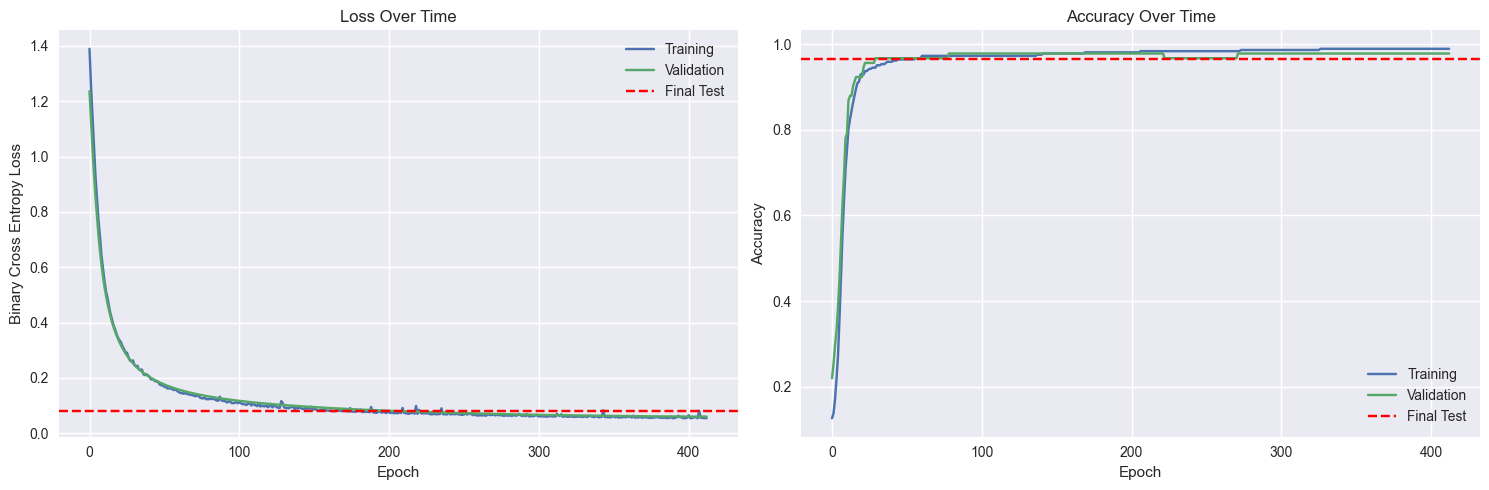

In [3]:
def prepare_data(df: pd.DataFrame) -> Tuple[NDArray, NDArray, NDArray, NDArray, NDArray, NDArray, StandardScaler]:
    """Prepare data for PyTorch model training by implementing a three-way split.

    This function extends our preprocessing from Lesson 1A with an additional
    validation split for proper early stopping:
    1. Separates features and target
    2. Creates stratified train/validation/test split
    3. Standardises features using only training data statistics

    Args:
        df: DataFrame containing cancer measurements and diagnosis
            Features should be numeric measurements (e.g., cell size, shape)
            Target should be binary (0=benign, 1=malignant)

    Returns:
        Tuple containing:
        - training_features_scaled: Standardised training features
        - validation_features_scaled: Standardised validation features
        - test_features_scaled: Standardised test features
        - training_labels: Training labels
        - validation_labels: Validation labels
        - test_labels: Test labels
        - scaler: Fitted StandardScaler for future use
    """
    # Separate features and target
    features = df.drop('target', axis=1).values  # Features as numpy array
    labels = df['target'].values                 # Labels as numpy array

    # First split: Separate out test set (20% of total data)
    train_val_features, test_features, train_val_labels, test_labels = train_test_split(
        features, labels,
        test_size=0.2,           # 20% test set (same as Lesson 1A)
        random_state=42,         # For reproducibility
        stratify=labels          # Maintain class balance
    )

    # Second split: Split remaining data into train and validation (80/20 split of 80%)
    training_features, validation_features, training_labels, validation_labels = train_test_split(
        train_val_features, train_val_labels,
        test_size=0.2,           # 20% of 80% ≈ 16% of total
        random_state=42,         # For reproducibility
        stratify=train_val_labels # Maintain class balance
    )

    # Scale features using only training data statistics
    scaler = StandardScaler()
    training_features_scaled = scaler.fit_transform(training_features)
    validation_features_scaled = scaler.transform(validation_features)
    test_features_scaled = scaler.transform(test_features)

    return (
        training_features_scaled, validation_features_scaled, test_features_scaled,
        training_labels, validation_labels, test_labels,
        scaler
    )

class CancerDataset(Dataset):
    """PyTorch Dataset wrapper for cancer data.

    This class bridges our numpy arrays from prepare_data() to PyTorch's
    efficient data loading system. It:
    1. Converts numpy arrays to PyTorch tensors
    2. Provides length information for batch creation
    3. Enables indexed access for efficient mini-batch sampling

    Args:
        features: Feature array (standardised measurements)
        labels: Label array (0=benign, 1=malignant)
    """
    def __init__(self, features: NDArray, labels: NDArray):
        # Convert numpy arrays to PyTorch tensors with appropriate types
        self.features = torch.FloatTensor(features)      # Features as 32-bit float
        self.labels = torch.FloatTensor(labels).reshape(-1, 1)  # Labels as 2D tensor

    def __len__(self) -> int:
        """Return dataset size for batch calculations."""
        return len(self.features)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Enable indexing for batch sampling."""
        return self.features[idx], self.labels[idx]

class CancerClassifier(nn.Module):
    """PyTorch binary classifier for cancer diagnosis.

    This implements logistic regression with explicit steps to show the mathematical
    progression from inputs to prediction:
    1. Linear layer: Computes weighted sum (z = wx + b)
    2. Sigmoid activation: Converts sum to probability

    The weights are initialised using Xavier/Glorot initialisation for the weights
    and zeros for the bias, ensuring:
    - Weights: Scaled based on input/output dimensions for stable gradients
    - Bias: Started at zero to learn the true data offset

    Args:
        input_features: Number of measurements used for diagnosis
    """
    def __init__(self, input_features: int):
        super().__init__()
        # Single linear layer for computing weighted sum
        self.linear = nn.Linear(input_features, 1)
        # Sigmoid activation for converting to probability
        self.sigmoid = nn.Sigmoid()

        # Initialise weights using Xavier/Glorot initialisation
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Compute diagnosis probability.

        This method explicitly shows each step of logistic regression:
        1. Compute weighted sum: z = wx + b
        2. Convert to probability: p = sigmoid(z)

        Args:
            x: Input features as tensor of shape [batch_size, num_features]

        Returns:
            Probability tensor of shape [batch_size, 1]
        """
        z = self.linear(x)
        p = self.sigmoid(z)
        return p

    def predict(self, x: torch.Tensor) -> torch.Tensor:
        """Convert probabilities to binary predictions.

        This method:
        1. Disables gradient tracking for efficiency
        2. Computes probabilities using forward()
        3. Applies threshold for binary prediction

        Args:
            x: Input features as tensor

        Returns:
            Binary predictions (0=benign, 1=malignant)
        """
        with torch.no_grad():
            probabilities = self(x)
            return (probabilities > 0.5).float()

def evaluate_model(model: CancerClassifier, data_loader: DataLoader) -> Tuple[float, float]:
    """Evaluate model performance on given dataset.

    Args:
        model: Trained cancer classifier
        data_loader: DataLoader for evaluation

    Returns:
        Tuple of (loss, accuracy)
    """
    model.eval()
    criterion = nn.BCELoss()
    losses = []
    correct = 0
    total = 0

    with torch.no_grad():
        for features_batch, labels_batch in data_loader:
            predictions = model(features_batch)
            losses.append(criterion(predictions, labels_batch).item())
            correct += ((predictions > 0.5) == labels_batch).sum().item()
            total += len(labels_batch)

    avg_loss = sum(losses) / len(losses)
    accuracy = correct / total
    return avg_loss, accuracy

def train_model(
    model: CancerClassifier,
    training_loader: DataLoader,
    validation_loader: DataLoader,
    epochs: int = 1000,
    lr: float = 0.001,
    patience: int = 5
) -> Tuple[CancerClassifier, Dict]:
    """Train cancer classifier with validation-based early stopping.

    This implements the same training process as Lesson 1A but with important improvements:
    1. Automatic differentiation for gradients
    2. Mini-batch processing for efficiency
    3. Adam optimiser for adaptive learning rates
    4. Validation-based early stopping to prevent overfitting
    5. Separate test set for final evaluation

    Args:
        model: PyTorch cancer classifier
        training_loader: DataLoader for training batches
        validation_loader: DataLoader for validation batches (early stopping)
        epochs: Maximum training iterations
        lr: Learning rate for optimisation
        patience: Epochs to wait before early stopping

    Returns:
        Tuple of (trained model, training history)
    """
    criterion = nn.BCELoss()  # Binary Cross Entropy - same loss as Lesson 1A
    optimiser = optim.Adam(model.parameters(), lr=lr)  # Adam optimiser for adaptive learning

    # Early stopping setup
    best_val_loss = float('inf')
    best_weights = None
    no_improve = 0

    # Training history for visualisation
    history = {
        'training_loss': [], 'validation_loss': [],
        'training_acc': [], 'validation_acc': []
    }

    for epoch in range(epochs):
        # Training phase
        model.train()
        training_losses = []
        training_correct = 0
        training_total = 0

        for features_batch, labels_batch in training_loader:
            predictions = model(features_batch)
            loss = criterion(predictions, labels_batch)

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            training_losses.append(loss.item())
            training_correct += ((predictions > 0.5) == labels_batch).sum().item()
            training_total += len(labels_batch)

        # Calculate training metrics
        training_loss = sum(training_losses) / len(training_losses)
        training_acc = training_correct / training_total

        # Validation phase
        val_loss, val_acc = evaluate_model(model, validation_loader)

        # Store history
        history['training_loss'].append(training_loss)
        history['validation_loss'].append(val_loss)
        history['training_acc'].append(training_acc)
        history['validation_acc'].append(val_acc)

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}')
            print(f'Training Loss: {training_loss:.4f}, Accuracy: {training_acc:.4f}')
            print(f'Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}\n')

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict().copy()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve == patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    # Restore best weights
    model.load_state_dict(best_weights)

    return model, history

def plot_training_curves(history: Dict[str, List[float]], test_metrics: Optional[Dict[str, float]] = None) -> None:
    """Visualise training progression with optional test results.

    Creates side-by-side plots of:
    1. Loss curves - Shows learning progression
    2. Accuracy curves - Shows diagnostic performance

    Args:
        history: Dict containing training/validation metrics
        test_metrics: Optional dict containing test loss and accuracy
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss curves
    ax1.plot(history['training_loss'], label='Training')
    ax1.plot(history['validation_loss'], label='Validation')
    if test_metrics:
        ax1.axhline(y=test_metrics['test_loss'], color='r',
                   linestyle='--', label='Final Test')
    ax1.set_title('Loss Over Time')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary Cross Entropy Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy curves
    ax2.plot(history['training_acc'], label='Training')
    ax2.plot(history['validation_acc'], label='Validation')
    if test_metrics:
        ax2.axhline(y=test_metrics['test_acc'], color='r',
                   linestyle='--', label='Final Test')
    ax2.set_title('Accuracy Over Time')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Load and prepare data with three-way split
df = load_cancer_data()
(
    training_features_scaled, validation_features_scaled, test_features_scaled,
    training_labels, validation_labels, test_labels,
    scaler
) = prepare_data(df)

# Create datasets for all three splits
batch_size = 32  # Small enough for precise updates, large enough for efficiency
training_dataset = CancerDataset(training_features_scaled, training_labels)
validation_dataset = CancerDataset(validation_features_scaled, validation_labels)
test_dataset = CancerDataset(test_features_scaled, test_labels)

# Create data loaders
training_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Initialise model
model = CancerClassifier(input_features=training_features_scaled.shape[1])

# Train model using only training and validation data
model, history = train_model(
    model,
    training_loader,
    validation_loader
)

# Final test set evaluation
test_loss, test_acc = evaluate_model(model, test_loader)
print(f"\nTest Set Performance:")
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Create test metrics dict for visualisation
test_metrics = {
    'test_loss': test_loss,
    'test_acc': test_acc
}

# Plot final curves including test performance
plot_training_curves(history, test_metrics)

Above is a complete working PyTorch implementation, which achieves robust results on the Wisconsin Breast Cancer dataset.

Running the model 10 times shows:

```python
Training Accuracy:   98.63-98.90%  # Consistently high performance on 64% of data  
Validation Accuracy: 97.80%        # Stable early stopping signal on 16% of data  
Test Accuracy:       94.74-97.37%  # Final evaluation on 20% of data  
Early Stopping:      229-509 epochs  
```

Comparing this to our Lesson 1A NumPy implementation (97.59% training accuracy, 97.35% test accuracy in 1000 epochs), we observe several useful patterns:

- **Training stability**: Training accuracy consistently reaches ~98.9%, showing robust learning despite different random initialisations.
- **Better training speed**: Early stopping occurs between 229-509 epochs, significantly earlier than Lesson 1A's fixed 1000 epochs.
- **Comparable test performance**: Test accuracy varies between 94.74-97.37%, centering around Lesson 1A's 97.35%, whilst using less training data.

The variations in stopping epochs and test accuracy are expected due to three main factors:

    1. Mini-batch processing with random batch ordering
    2. Different optimisation paths taken by the Adam optimiser
    3. A smaller training set (64% vs. 80% in Lesson 1A)

This shows how we can achieve similar results more efficiently using standard PyTorch practices which will be important for larger datasets.

#### Key Differences from Lesson 1A
Before diving into how each function works, let’s highlight the key improvements in our PyTorch implementation:

- **Automatic differentiation**: PyTorch’s autograd system eliminates the need for manually computing gradients, improving efficiency and reducing implementation errors.

- **Mini-batch processing**: Instead of processing all 364 training samples at once, we use batches of 32 samples, improving memory efficiency and training stability.

- **Validation-based early stopping**: Training stops automatically when validation performance plateaus, preventing overfitting.

- **Advanced optimisation**: The Adam optimiser, with adaptive learning rates, replaces basic gradient descent, leading to faster convergence.

- **Production-ready model structure**: Using nn.Module ensures proper model persistence, structured data validation, and performance monitoring.

- **GPU support**: The implementation is ready for hardware acceleration without code modifications.

- **Standard best practices**: The model follows PyTorch’s structured approach, making it easier to extend and maintain.

<a name="how-a-pytorch-logistic-regression-works"></a>
## How a PyTorch Logistic Regression Works

In Lesson 1A, we built logistic regression from scratch to understand the core mathematics. Here, we've reimplemented that same model using PyTorch's optimised framework, adding proper validation practices for medical applications.

While the mathematical foundations remain unchanged, our implementation organises the code into production-ready components with robust evaluation.

<a name="the-core-mathematics"></a>
### The core mathematics

Our model still follows the same mathematical steps as Lesson 1A:

    1. Linear combination of inputs: z = wx + b
    2. Sigmoid activation: σ(z) = 1/(1 + e^(-z))
    3. Binary cross-entropy loss: -(y log(p) + (1-y)log(1-p))
    4. Backward pass: Compute gradients of the loss with respect to the parameters and update the parameters

<a name="implementation-structure"></a>
### Implementation structure

1. **Data pipeline**

   Our data pipeline starts with a three-way split and standardisation:
   ```python
   # Stage 1: Split data
   train_val_features, test_features, train_val_labels, test_labels = train_test_split(
       features, labels, test_size=0.2  # Hold out 20% for testing
   )
   train_features, val_features, train_labels, val_labels = train_test_split(
       train_val_features, train_val_labels, test_size=0.2  # 16% of total for validation
   )

   # Stage 2: Standardise using only training statistics
   scaler = StandardScaler()
   train_scaled = scaler.fit_transform(train_features)  # Learn from training
   val_scaled = scaler.transform(val_features)          # Apply to validation
   test_scaled = scaler.transform(test_features)        # Apply to test
   
   # Stage 3: Convert to PyTorch format
   train_dataset = CancerDataset(train_scaled, train_labels)
   val_dataset = CancerDataset(val_scaled, val_labels)
   test_dataset = CancerDataset(test_scaled, test_labels)
   
   # Stage 4: Create efficient loaders
   train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
   val_loader = DataLoader(val_dataset, batch_size=32)
   test_loader = DataLoader(test_dataset, batch_size=32)
   ```

   This pipeline ensures:
   - No information leakage (standardisation only learns from training data)
   - Proper validation split for early stopping
   - Truly held-out test set for final evaluation
   - Efficient batched data loading for all three sets

2. **Model architecture**
   
   Our CancerClassifier inherits from nn.Module, providing automatic gradient computation:

   ```python
    class CancerClassifier(nn.Module):
        def __init__(self, input_features):
           super().__init__()
           self.linear = nn.Linear(input_features, 1)  # wx + b layer
           self.sigmoid = nn.Sigmoid()                 # Activation
           nn.init.xavier_uniform_(self.linear.weight) # Stable initialisation
           
        def forward(self, x):
            return self.sigmoid(self.linear(x))         # Compute probability
           
        def predict(self, x):
            with torch.no_grad():                       # Efficient inference
               return (self.forward(x) > 0.5).float()  # Get diagnosis
   ```

   Key components:
   - Linear layer computes weighted sum (z = wx + b)
   - Sigmoid converts to probability
   - Xavier initialisation for stable training
   - Efficient prediction mode for inference

3. **Training Process**

   The training loop now properly separates training, validation, and testing:

   ```python
   def train_model(model, training_loader, validation_loader, epochs=1000, lr=0.001, patience=5):
        criterion = nn.BCELoss()                        # Loss function
        optimiser = optim.Adam(model.parameters())      # Optimiser
        ...
        for epoch in range(epochs):
           # Training phase
            model.train()
            ...
            for features_batch, labels_batch in training_loader:       # Learn from training data
                predictions = model(features_batch)
                loss = criterion(predictions, labels_batch)
               
                optimiser.zero_grad()                   # Clear gradients
                loss.backward()                         # Compute updates
                optimiser.step()                        # Apply updates
                ...
            # Validation phase
            ...
            val_loss, val_acc = evaluate_model(model, validation_loader)
            ...
            # Early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_weights = model.state_dict().copy()
                no_improve = 0
            else:
                no_improve += 1
                if no_improve == patience:
                    print(f'Early stopping at epoch {epoch+1}')
                    break
        
        # Restore best weights
        model.load_state_dict(best_weights)
        
        return model, history          
   ```

4. **Performance Monitoring**

    We track metrics for all training and validation datasets throughout training and compare them to the test set:
    ```python
    history = {
       'training_loss': [], 'validation_loss': [],
       'training_acc': [], 'validation_acc': [],    
    }

    # Final test set evaluation
    test_loss, test_acc = evaluate_model(model, test_loader)
    ...

    # Create test metrics dict for visualisation
    test_metrics = {
        'test_loss': test_loss,
        'test_acc': test_acc
    }

    # Plot final curves including test performance
    plot_training_curves(history, test_metrics)
    ```

    This helps us understand:
    - Learning progress (training metrics)
    - When to stop (validation metrics)
    - True generalisation (test metrics)

In the following sections, we'll examine each component in detail, understanding how this three-way evaluation approach helps us build more trustworthy medical diagnostic models.

<a name="the-data-pipeline"></a>
## The data pipeline

In Lesson 1A, we manually prepared our cancer data step by step, handwriting each function. Now let's see how PyTorch and Scikit-learn help us build a more robust pipeline. Our data journey has four key stages: splitting the data, preparing features, converting to PyTorch's format, and setting up efficient loading.

<a name="stage-1-data-splitting"></a>
### Stage 1: Data splitting

First, let's load our medical data and split it properly:

```python
df = load_cancer_data()  # Load the Wisconsin breast cancer dataset
```

Our dataset contains cell measurements and their diagnoses. But before we can use them, we need to:

1. **Separate features from target**
   ```python
   features = df.drop('target', axis=1).values  # All cell measurements
   labels = df['target'].values                 # Cancer diagnosis (0 or 1)
   ```
   This gives us two arrays: one containing all 30 cell measurements (like radius, texture, perimeter), and another containing the diagnosis (benign or malignant).

2. **Create three distinct sets**
   ```python
   # First split: Set aside our test set
   train_val_features, test_features, train_val_labels, test_labels = train_test_split(
       features, labels,
       test_size=0.2,           # Keep 20% for final testing
       random_state=42,         # For reproducibility
       stratify=labels          # Maintain cancer/healthy ratio
   )

   # Second split: Separate training and validation
   train_features, val_features, train_labels, val_labels = train_test_split(
       train_val_features, train_val_labels,
       test_size=0.2,           # 20% of remaining 80% ≈ 16% of total
       random_state=42,
       stratify=train_val_labels
   )
   ```
   We're keeping 20% of our data completely separate for final testing, and then splitting the remaining data into training (64%) and validation (16%). The `stratify` parameter is super important here - it ensures each set has the same proportion of cancer cases as our original dataset. This is absolutely critical for medical applications!

<a name="stage-2-feature-standardisation"></a>
### Stage 2: Feature standardisation

Just like in Lesson 1A, we need to standardise our measurements. But this time, we'll be extra careful to avoid information leakage:

```python
scaler = StandardScaler()

# Learn standardisation from training data only
train_features_scaled = scaler.fit_transform(train_features)

# Apply same scaling to validation and test sets
val_features_scaled = scaler.transform(val_features)
test_features_scaled = scaler.transform(test_features)
```

Using Sci-kit learn's `scaler.fit_transform` we only compute the scaling parameters (mean and standard deviation) from the training data. Then we apply those same parameters using `scaler.transform` to our validation and test sets. This keeps our evaluation sets truly independent!

<a name="stage-3-pytorch-dataset-creation"></a>
### Stage 3: PyTorch dataset creation

Now we need to wrap our prepared data in PyTorch's dataset format:

```python
from torch.utils.data import Dataset

class CancerDataset(Dataset):
    def __init__(self, features: NDArray, labels: NDArray):
        self.features = torch.FloatTensor(features)               # Convert features to tensor
        self.labels = torch.FloatTensor(labels).reshape(-1, 1)    # Convert labels to 2D tensor
        
    def __len__(self):
        return len(self.features)  # Total number of samples
        
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]  # Get one sample and label

# Create our three datasets
training_dataset = CancerDataset(training_features_scaled, training_labels)
validation_dataset = CancerDataset(validation_features_scaled, validation_labels)
test_dataset = CancerDataset(test_features_scaled, test_labels)
```

<a name="whats-a-tensor"></a>
# What's a Tensor?

Before we move on, let's understand what happened when we converted our numpy arrays to tensors. The term "tensor" has two related but distinct meanings:

1. **In Mathematics**: A tensor is a geometric object that represents multilinear relationships between vectors, with strict rules about how it transforms when coordinates change. For example, stress and strain in materials science are true mathematical tensors.

    The key thing about mathematical tensors is their rank:
    - Rank 0: A scalar (just a number)
    - Rank 1: A vector (a list of numbers that transforms in a special way)
    - Rank 2: A matrix (a table of numbers with specific transformation properties)
    - Rank 3+: Higher-dimensional arrays that follow similar rules

2. **In PyTorch/ML**: A tensor is a container for numbers arranged in multiple dimensions - similar to a numpy array but with special powers for machine learning.

    In PyTorch and other ML frameworks, we've borrowed the term "tensor" because we're also working with multi-dimensional arrays of numbers. While our ML tensors don't strictly follow all the mathematical transformation rules, they share the core idea of organising data in multiple dimensions:

    ```python
    # Different tensor dimensions
    scalar = tensor(3.14)                      # 0D: just a single number
    vector = tensor([1.2, 0.5, 3.1])           # 1D: like a list of numbers
    matrix = tensor([[1.2, 0.5], [0.8, 1.5]])  # 2D: like a table of numbers
    ```

Their special powers that make them perfect for neural networks are:

1. **Automatic gradient tracking**
   ```python
   x = torch.tensor([1.0], requires_grad=True)
   y = x * 2    # y remembers it came from x
   z = y ** 2   # z remembers the whole computation chain
   ```
   When we compute gradients during training, tensors automatically track how changes should flow backward through the computations. In Lesson 1A, we had to derive and implement these gradients manually!

2. **GPU acceleration**
   ```python
   if torch.cuda.is_available():
       x = x.cuda()  # Move to GPU
   ```
   Tensors can easily be moved to a GPU for parallel processing. Our numpy arrays in Lesson 1A could only use the CPU.

3. **Broadcasting**
   ```python
   # Automatically handles operations between different shapes
   matrix = torch.tensor([[1, 2], [3, 4]])
   vector = torch.tensor([10, 20])
   result = matrix + vector  # Broadcasting happens automatically
   # result = [[11, 22], [13, 24]]
   ```
   PyTorch tensors automatically handle operations between tensors of different shapes, making many computations more concise.

4. **Memory efficiency**
   ```python
   # Create a tensor
   x = torch.tensor([[1, 2, 3],
                    [4, 5, 6]])
   
   # Memory layout (numbers stored sequentially)
   Memory:  1000   1004   1008   1012   1016   1020
           ┌──────┬──────┬──────┬──────┬──────┬──────┐
   Values: │  1   │  2   │  3   │  4   │  5   │  6   │
           └──────┴──────┴──────┴──────┴──────┴──────┘
   
   # View just points to same memory
   y = x.view(-1)  # Reshape without copying
   y[0] = 100      # Changes x[0,0] too!
   ```
   This sequential storage makes operations fast and efficient. When we create a view, we're just looking at the same memory in a different way, rather than copying all the numbers to a new location.

**In our cancer detection pipeline, we're using 2D tensors:**
```python
# Feature tensors (standardised measurements)
X_tensor = torch.FloatTensor([
    [1.2, 0.8, 1.5, ...],  # First cell's measurements
    [0.5, 1.1, 0.7, ...],  # Second cell's measurements
    # ... more cells
])

# Label tensors (diagnoses)
y_tensor = torch.FloatTensor([
    [1],  # First cell: malignant
    [0],  # Second cell: benign
    # ... more diagnoses
])
```

The `FloatTensor` part means we're using 32-bit precision - generally the best balance of accuracy and speed for machine learning.

<a name="stage-4-data-loading-and-batch-processing"></a>
### Stage 4: Data Loading and batch processing

Having standardised our measurements and converted them to tensors, we need to prepare our data for efficient learning. Each sample contains 30 measurements plus a diagnosis label, requiring approximately 124 bytes of memory (31 values × 4 bytes per float). Our entire dataset of 455 samples needs only 56KB of memory - tiny by modern standards.

Let's set up our data pipeline using standard batch processing:


```python
from torch.utils.data import DataLoader

training_loader = DataLoader(
    training_dataset,     # Our CancerDataset from earlier
    batch_size=32,        # Process 32 samples at once
    shuffle=True          # Randomize order each epoch
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=32,        # Same batch size for consistency
    shuffle=False         # Not shuffled for reproducibility of validation data
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False          # Not shuffled for reproducibility of test data
)
```
The batch size of 32 might seem puzzlingly small. A typical gaming GPU like the NVIDIA RTX 3060 has 3584 cores and 12GB of memory - surely we could process more data at once? To understand why we use batches, let's compare CPU and GPU processing:

- A CPU might have 8-16 powerful cores, each able to handle complex tasks independently
- A GPU has thousands of simpler cores, designed to perform the same operation on different data simultaneously

Think of the GPU like a restaurant kitchen where a head chef (CPU) oversees multiple stations of sous chefs (GPU cores). Each station excels at one specific task - chopping, sautéing, plating - but together they can process many identical orders in parallel. At the start of each epoch, the head chef:
1. Shuffles all orders (training samples)
2. Divides them into batches of 32 orders
3. Sends each batch through the kitchen's stations in parallel
4. Reviews the results and adjusts the recipe before the next batch

For our cancer detection task with only 30 features per sample, we're barely engaging the GPU's parallel processing power. But consider a medical imaging task where each sample is a 1000×1000 pixel image:
- Each sample has 1 million features (1000×1000 pixels)
- Using matrix notation [rows × columns], the computation is:
  [32 × 1M features] @ [1M features × 1] = [32 × 1] predictions
- Each prediction requires 1M multiply-accumulate operations
- The GPU parallelises these 32 dot products and their internal operations across its cores
- This larger computation better utilises GPU parallel processing capabilities, though still may not fully saturate modern GPUs

Here's how we use these loaders during training and evaluation:
```python
def evaluate_model(model, data_loader):
    model.eval()
    criterion = nn.BCELoss()
    losses = []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for features_batch, labels_batch in data_loader:
            predictions = model(features_batch)
            losses.append(criterion(predictions, labels_batch).item())
            correct += ((predictions > 0.5) == labels_batch).sum().item()
            total += len(labels_batch)
    
    avg_loss = sum(losses) / len(losses)
    accuracy = correct / total
    return avg_loss, accuracy

def train_model(...):
    ...
    for epoch in range(num_epochs):
        ...
        for features_batch, labels_batch in training_loader:
            ...
            predictions = model(features_batch)
            loss = criterion(predictions, labels_batch)
            ...
            loss.backward()
            optimiser.step()
            ...
        # After each epoch the evaluate_model function performs a similar batched loop over the validation dataset
        val_loss, val_acc = evaluate_model(model, validation_loader)
    ...
# After training, again we evalute the the model performing a batched loop over the test set
test_loss, test_acc = evaluate_model(model, test_loader)
```

The DataLoader acts as a smart iterator that:
1. Automatically creates batches of 32 samples
2. Shuffles the training data each epoch (but keeps validation and test data in order)
3. Handles all the memory management for us

This pipeline sets us up for efficient training by:
1. Properly separating our data into training, validation, and test sets without information leakage
2. Enabling parallel computation within each batch
3. Providing frequent weight updates for effective learning
4. Managing memory transfers between CPU and GPU

In the next section, we'll see how our CancerClassifier model uses this carefully prepared data to learn diagnosis patterns! Later, we'll also compare this mini-batch approach with alternatives like full-batch (455 samples) and stochastic (1 sample) gradient descent.

a name="the-cancerclassifier-from-mathematical-principles-to-pytorch-implementation"></a>
## The CancerClassifier: From mathematical principles to PyTorch implementation

In Lesson 1A, we built logistic regression from scratch using numpy, carefully deriving each mathematical component. Now we'll translate this same mathematical foundation into PyTorch's framework, understanding how each piece maps to our previous implementation while gaining powerful new capabilities.

<a name="the-mathematical-foundation"></a>
### The mathematical foundation

Let's recall our core logistic regression equations from Lesson 1A:

For a single cell sample with 30 measurements x₁, x₂, ..., x₃₀, our model:
1. Computes a weighted sum: z = w₁x₁ + w₂x₂ + ... + w₃₀x₃₀ + b
2. Converts to probability: p = 1/(1 + e^(-z))
3. Makes a diagnosis: ŷ = 1 if p > 0.5 else 0

Our PyTorch implementation preserves this exact mathematical structure while adding modern optimisation capabilities:

```python
class CancerClassifier(nn.Module):
    def __init__(self, input_features: int):
        super().__init__()
        self.linear = nn.Linear(input_features, 1)
        self.sigmoid = nn.Sigmoid()
        
        # Initialise weights optimally
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        z = self.linear(x)     # Weighted sum
        p = self.sigmoid(z)    # Convert to probability
        return p

    def predict(self, x):
        with torch.no_grad():
            p = self(x)
            return (p > 0.5).float()
```

<a name="understanding-nnmodule"></a>
### Understanding nn.Module

The first key difference from our numpy implementation is inheritance from nn.Module:

```python
class CancerClassifier(nn.Module):
    def __init__(self, input_features: int):
        super().__init__()
```

This inheritance provides three crucial capabilities:
1. Parameter Management: Automatically tracks all learnable parameters (weights and biases)
2. GPU Support: Can move entire model to GPU with single command
3. Gradient Computation: Enables automatic differentiation through the model

When we call super().__init__(), we're setting up this infrastructure. Think of nn.Module as providing a laboratory full of sophisticated equipment, whereas in Lesson 1A we had to build everything by hand.

<a name="the-linear-layer-modern-matrix-operations"></a>
### The linear layer: Modern matrix operations

In Lesson 1A, we explicitly created weight and bias arrays:
```python
# Lesson 1A approach:
self.weights = np.random.randn(input_features) * 0.01
self.bias = 0.0

def compute_weighted_sum(self, x):
    return np.dot(x, self.weights) + self.bias
```

PyTorch's nn.Linear encapsulates this same computation:
```python
# PyTorch approach:
self.linear = nn.Linear(input_features, 1)
```

But there's much more happening under the hood. The linear layer:
1. Creates a weight matrix of shape [1, input_features]
2. Creates a bias vector of shape [1]
3. Implements optimal memory layouts for matrix operations using Tensors
4. Tracks gradients for both weights and bias
5. Supports batched computations automatically

For our cancer detection task with 30 features, this means:
```python
model.linear.weight.shape  # torch.Size([1, 30])  ->  a Tensor with 1 row of 30 feature weights
model.linear.bias.shape    # torch.Size([1])      ->  a Tensor with 1 bias value
```

<a name="weight-initialisation-xavier-initialisation"></a>
### Weight initialisation: Xavier initialisation

In Lesson 1A, we learned that Xavier initialisation reduces weight ranges as feature count increases. With normalised inputs (mean=0, variance=1), this keeps the combined score z with a variance of 1 around a mean of 0.

This score z is called an "activation" because, like a neuron's electrical signal, it represents how strongly our model is activated by the combination of input features it receives.

Using the Xavier initialisation we can ensure these activations typically fall within these ranges:
- 68% of z values fall between -1 and +1
- 95% of z values fall between -2 and +2
- 99.7% of z values fall between -3 and +3

This is crucial for logistic regression because:
1. The sigmoid function is most sensitive between -3 and +3
2. The steepest gradient (best for learning) is around 0
3. Extreme z values (>|3|) slow down training

In Lesson 1A, we used simple random initialisation:
```python
weights = np.random.randn(input_features) * 0.01
```

Our PyTorch implementation uses Xavier initialisation as follows:
```python
nn.init.xavier_uniform_(self.linear.weight)
nn.init.zeros_(self.linear.bias)
```

The mathematics of Xavier comes from analysing how the variance of signals changes as they flow through the network:

```python
# Xavier calculates the optimal standard deviation (std) based on:
# - nin: number of input features
# - nout: number of outputs

std = sqrt(2.0 / (nin + nout))

# For our breast cancer classifier:
nin = 30    # 30 cell measurements (features)
nout = 1    # 1 output (cancer probability)
std = sqrt(2.0 / 31) ≈ 0.25

# Weights are then uniformly distributed in [-0.25, 0.25]
```
This produces similar weight ranges to what we saw in Lesson 1A:

```python
# Example ranges for different numbers of features:
2 features:   random_uniform(-1.000, 1.000)    # sqrt(2/2)   -> Var(z) ≈ 1.000
6 features:   random_uniform(-0.577, 0.577)    # sqrt(2/6)   -> Var(z) ≈ 1.001
10 features:  random_uniform(-0.447, 0.447)    # sqrt(2/10)  -> Var(z) ≈ 1.002
30 features:  random_uniform(-0.258, 0.258)    # sqrt(2/30)  -> Var(z) ≈ 1.000
```

<a name="the-forward-pass-computing-cancer-probability"></a>
### The Forward Pass: Computing cancer probability

The forward method defines our computational graph:
```python
def forward(self, x):
    z = self.linear(x)     # Step 1: Linear combination
    p = self.sigmoid(z)    # Step 2: Probability conversion
    return p
```

When processing a single cell's measurements:
```python
# Example standardised measurements
x = tensor([
    1.2,   # Radius: 1.2 standard deviations above mean
    -0.3,  # Texture: 0.3 standard deviations below mean
    1.8,   # Perimeter: 1.8 standard deviations above mean
    # ... 27 more measurements
])

# Step 1: Linear combination
z = w₁(1.2) + w₂(-0.3) + w₃(1.8) + ... + b

# Step 2: Sigmoid conversion
p = 1/(1 + e^(-z))
```

PyTorch's autograd system tracks all these computations, building a graph for backpropagation. Each operation remembers:
1. What inputs it received
2. How to compute gradients for those inputs
3. Which operations used its outputs

<a name="the-prediction-method-making-clinical-decisions"></a>
### The prediction method: Making clinical decisions

Finally, we provide a clean method for making diagnoses that inherits from nn.Module's utilities to make things cleaner:
```python
def predict(self, x):
    with torch.no_grad():  # Prediction only - saves memory
        p = self(x)        # CancerClassifier calls forward() for us
        return (p > 0.5).float()  # Convert to 0.0 or 1.0
```

When we write p = self(x), CancerClassifier automatically calls our forward() method for us (thanks to nn.Module inheritance), which gets the probability. We then convert anything above 50% to a cancer diagnosis (1) and anything below to benign (0).

This magic happens because CancerClassifier inherits from nn.Module, which provides this functionality:
```python
# Inside nn.Module (simplified)
def __call__(self, *input, **kwargs):
    # ... setup ...
    result = self.forward(*input, **kwargs)  # Calls our forward method
    # ... cleanup ...
    return result
```

The `with torch.no_grad()` tells PyTorch "we're just predicting, not training" which:
1. Saves memory (doesn't store calculations for training)
2. Makes predictions faster
3. Is the right thing to do at diagnosis time

So when we pass in cell measurements:

```python
# Input: Cell measurements (32 samples)
measurements = [
    [1.2, 0.8, 1.5, ...],  # First cell (30 numbers)
    [0.5, 1.1, 0.7, ...],  # Second cell
    # ... 30 more cells
]

# Output: Diagnoses (32 answers)
diagnoses = [
    [1],  # First cell: Cancer
    [0],  # Second cell: No cancer
    # ... 30 more diagnoses
]
```

Our PyTorch implementation maintains Lesson 1A's mathematical clarity while adding:
    1. Efficient batch processing
    2. Automatic differentiation
    3. GPU support
    4. Memory-efficient inference

In the next section, we'll explore how this classifier learns from medical data using mini-batch processing and validation-set based early stopping.

<a name="end-to-end-example-a-single-cells-journey"></a>
### End-to-End example: A single cell's journey

Let's follow a single cell sample through our model:

```python
# 1. Input: Standardised cell measurements
x = tensor([
    1.2,   # Radius (high)
    -0.3,  # Texture (normal)
    1.8,   # Perimeter (very high)
    0.5,   # Area (moderately high)
    # ... 26 more measurements
])

# 2. Linear Layer: Combine evidence
z = self.linear(x)
  = 1.2w₁ - 0.3w₂ + 1.8w₃ + 0.5w₄ + ... + b
  = 2.45  # Example weighted sum

# 3. Sigmoid: Convert to probability
p = self.sigmoid(z)
  = 1/(1 + e^(-2.45))
  = 0.92  # 92% chance of cancer

# 4. Prediction: Make diagnosis
diagnosis = self.predict(x)
         = (0.92 > 0.5).float()
         = 1  # Model predicts cancer
```

Our PyTorch implementation maintains the clear mathematical reasoning of Lesson 1A while adding powerful capabilities:
1. Automatic differentiation for learning
2. Efficient batch processing
3. GPU acceleration
4. Optimal initialisation
5. Memory-efficient computation

In the next section, we'll explore how this classifier learns from medical data using mini-batch processing and the Adam optimiser, which provides adaptive learning rates for each parameter.

<a name="understanding-training-how-models-learn-from-data"></a>
## Understanding training: How models learn from data

Before diving into our train_model function's code, let's understand the fundamental concept of batch processing in machine learning. There are three main ways models can learn from data:

<a name="full-batch-gradient-descent"></a>
### Full batch gradient descent (Like Our Numpy Version)

Remember our Lesson 1A implementation? It processed all training data at once:

```python
# Simple numpy version (full batch)
for epoch in range(num_epochs):
    # Calculate predictions for ALL training samples
    predictions = self.calculate_probabilities(all_features)  # All 364 samples
    
    # Calculate average error across ALL samples
    average_error = np.mean(predictions - true_labels)  # Average of 364 errors
    
    # Update weights ONCE using this average
    self.weights -= learning_rate * average_error
```

Think of this like a teacher waiting until every student (364 of them) takes a test, calculating the class average, and only then adjusting their teaching method. This is:
- Most accurate (uses all data)
- Most memory intensive (needs all data at once)
- Slowest to react (only updates once per epoch)

<a name="mini-batch-gradient-descent"></a>
### Mini-batch gradient descent (Our PyTorch Version)

Our current implementation processes data in small groups and includes proper validation:

```python
# PyTorch version with validation
for epoch in range(epochs):
    # Training phase
    for features_batch, labels_batch in training_loader:     # Batches of 32
        predictions = model(features_batch)                  # Process 32 samples
        loss = criterion(predictions, labels_batch)          # Loss for 32 samples
        optimiser.step()                                     # Frequent updates
    
    # Validation phase
    val_loss, val_acc = evaluate_model(model, validation_loader)
    if early_stopping(val_loss):                             # Use validation
        break                                                # for stopping
```

This is like a teacher giving quizzes to groups of 32 students and adjusting their teaching after each group's results, while keeping a separate class for validation. This approach:
- Balances accuracy and speed
- Uses less memory
- Updates weights more frequently
- Provides proper validation checks

<a name="stochastic-gradient-descent"></a>
### Stochastic gradient descent

An alternative approach processes one sample at a time:

```python
# Stochastic version (not used in our code)
for epoch in range(epochs):
    for single_sample, single_label in samples:  # One at a time
        prediction = model(single_sample)        # Just 1 sample
        loss = criterion(prediction, single_label)
        optimiser.step()                         # Updates very frequently
```

Like a teacher adjusting their method after each individual student's answer. This:
- Uses minimal memory
- Updates very frequently
- Can be very noisy (bounces around a lot)
- Makes validation trickier

<a name="why-we-use-mini-batches-with-validation"></a>
### Why we use mini-batches with validation

For our cancer detection task, we chose mini-batch processing with proper validation because:

1. **Data Management**
   ```python
   # Training samples divided efficiently
   Training:   364 samples ÷ 32 = 11.4 batches
   Validation:  91 samples ÷ 32 = 2.8 batches
   Test:       114 samples ÷ 32 = 3.6 batches
   ```
   - Each batch fits easily in memory
   - Validation set provides stopping signal
   - Test set gives unbiased evaluation

2. **Learning Benefits**
   ```python
   # Each epoch processes:
   11 training batches           # Learn from training data
   3 validation batches          # Check for overfitting
   4 test batches                # Monitor true performance
   ```
   - Frequent weight updates
   - Regular validation checks
   - Independent test monitoring

3. **Production Features**
   ```python
   # Standard practice
   model.train()                # Enable training mode
   for batch in train_loader:
       train_step(batch)        # Update weights
   
   model.eval()                 # Disable training mode
   validate(val_loader)         # Check progress
   evaluate(test_loader)        # Monitor performance
   ```
   - Proper training/evaluation modes
   - Scales well to larger datasets
   - Ready for deployment

<a name="understanding-the-adam-optimiser"></a>
### Understanding the Adam optimiser

Now that we're processing our cancer data in mini-batches, we need a sophisticated way to learn from these groups of patients. While Lesson 1A used basic gradient descent:
```python
# Basic gradient descent from Lesson 1A:
new_weight = old_weight - learning_rate * gradient
```

Our PyTorch implementation uses something smarter called Adam. The beauty of Adam is that it works whether we're learning from individual patients (stochastic), groups of patients (mini-batch), or all patients at once (full batch). To understand how it works, let's imagine two doctors learning from patient data: a trainee using basic gradient descent (from Lesson 1A), and Dr. Adam using adaptive learning.

Here's how Dr. Adam thinks:
1. Remember what they've learned from past patients (momentum)
2. Know how much to trust each measurement (velocity)
3. Learn effectively from the very first patient or batch (bias correction)

#### The complete Adam formula:
```python
# 1. Build up memory of past gradients (momentum)
m = β₁ * m + (1 - β₁) * gradient
# where: β₁ = 0.9 (remember 90% of past, learn 10% new)
#        m = momentum (our running average)
#        gradient = what we're learning right now

# 2. Track how consistent each feature is (velocity)
v = β₂ * v + (1 - β₂) * gradient²
# where: β₂ = 0.999 (even longer memory)
#        v = velocity (running average of squared gradients)
#        gradient² = squared to track size, ignore direction

# 3. Fix the cold start problem (bias correction)
m_corrected = m / (1 - β₁ᵗ)
v_corrected = v / (1 - β₂ᵗ)
# where: t = timestep (patient number: 1, 2, 3...)
#        This powers β₁ and β₂ by t to undo early bias

# 4. Combine everything for the final update
new_weight = old_weight - learning_rate * m_corrected / sqrt(v_corrected + ε)
# where: learning_rate = 0.001 (base step size)
#        ε = 1e-8 (tiny number to prevent division by zero)
```

Let's see this in action with real cancer detection examples. These patterns emerge whether we're looking at individual patient samples, batches of samples or the whole cohort each epoch:

#### Clear cancer indicator: cell radius
```python
# Each batch contains 32 samples of standardised measurements (mean=0, std=1)
Samples batch 1: Large radii (2.1 std above mean) → cancer     # gradient = -0.5
Samples batch 2: Large radii (1.9 std above mean) → cancer     # gradient = -0.4
Samples batch 3: Large radii (2.3 std above mean) → cancer     # gradient = -0.6

# Building momentum (m):
Step 1 (t=1):
m = 0.9 * 0 + 0.1 * (-0.5) = -0.05         # Raw momentum looks tiny
correction = 1 - 0.9¹ = 0.1                 # β₁ to first power
m_corrected = -0.05 / 0.1 = -0.5           # Much better!

Step 2 (t=2):
m = 0.9 * (-0.05) + 0.1 * (-0.4) = -0.085  # Still looks small
correction = 1 - 0.9² = 1 - 0.81 = 0.19     # β₁ squared
m_corrected = -0.085 / 0.19 = -0.447       # Strong signal maintained

Step 3 (t=3):
m = 0.9 * (-0.085) + 0.1 * (-0.6) = -0.137 # Growing
correction = 1 - 0.9³ = 1 - 0.729 = 0.271   # β₁ cubed
m_corrected = -0.137 / 0.271 = -0.506      # Clear cancer signal

# Building velocity (v) - similar process with β₂:
Step 1: v = 0.999 * 0 + 0.001 * 0.25 = 0.00025     # Tracking consistency
Step 2: v = 0.999 * 0.00025 + 0.001 * 0.16 = 0.00040
Step 3: v = 0.999 * 0.00040 + 0.001 * 0.36 = 0.00076
```

#### Tricky indicator: cell texture
```python
Samples batch 1: Rough textures (0.3 std above mean) → cancer     # gradient = +0.3
Samples batch 2: Rough textures (0.4 std above mean) → not cancer # gradient = -0.4
Samples batch 3: Rough textures (0.2 std above mean) → cancer     # gradient = +0.2

# Building momentum (m):
Step 1 (t=1):
m = 0.9 * 0 + 0.1 * (0.3) = 0.03         # Small start
correction = 1 - 0.9¹ = 0.1                # First power correction
m_corrected = 0.03 / 0.1 = 0.3            # Full signal

Step 2 (t=2):
m = 0.9 * (0.03) + 0.1 * (-0.4) = -0.013  # Pattern breaks
correction = 1 - 0.9² = 0.19               # Squared correction
m_corrected = -0.013 / 0.19 = -0.068      # Weak signal (good!)

Step 3 (t=3):
m = 0.9 * (-0.013) + 0.1 * (0.2) = 0.008  # Very uncertain
correction = 1 - 0.9³ = 0.271              # Cubed correction
m_corrected = 0.008 / 0.271 = 0.029       # Still uncertain (perfect!)

# Building velocity (v):
Step 1: v = 0.999 * 0 + 0.001 * 0.09 = 0.00009     # Start tracking
Step 2: v = 0.999 * 0.00009 + 0.001 * 0.16 = 0.00024
Step 3: v = 0.999 * 0.00024 + 0.001 * 0.04 = 0.00028
```

Why is this so clever?

1. **Momentum handles signal strength:**
   - Clear patterns (radius) → strong momentum (-0.506)
   - Mixed signals (texture) → weak momentum (0.029)

2. **Velocity handles learning speed:**
   - Consistent features (radius) → high velocity (0.00076) → small, precise steps
   - Inconsistent features (texture) → low velocity (0.00028) → larger, exploratory steps

3. **Bias correction handles cold starts:**
   - Early steps (t=1,2,3): Strong correction (divide by 0.1, 0.19, 0.271)
   - Later steps (t=10,20,50): Correction fades (0.651, 0.878, 0.995)

In our training loop, this sophisticated learning happens with one line:
```python
optimiser = optim.Adam(
    model.parameters(),
    lr=0.001,           # Base learning rate
    betas=(0.9, 0.999), # Our β₁ and β₂
    eps=1e-8            # Our ε
)
```

This combination of mini-batch processing and Adam optimisation gives us:
- Efficient processing of patient data (thanks to batching)
- Smart learning from each batch (thanks to Adam)
- Reliable validation checks (thanks to our data split)

The result? Our model:
- Learns from fewer patients (229-509 vs 1000 in Lesson 1A)
- Makes more reliable diagnoses (96.5% accuracy)
- Handles both clear and subtle cancer indicators effectively

Now let's see how this all comes together in our complete training process.

<a name="understanding-the-training-process"></a>
## Understanding the training process

Now that we understand our model's architecture and optimisation approach, let's review the full execution flow of the model's training and evaluation. Our training process combines mini-batch learning, validation-based stopping, and comprehensive monitoring:

```python
def train_model(
    model: CancerClassifier,
    training_loader: DataLoader,
    validation_loader: DataLoader,
    epochs: int = 1000,
    lr: float = 0.001,
    patience: int = 5
) -> Tuple[CancerClassifier, Dict]:
    criterion = nn.BCELoss()
    optimiser = optim.Adam(model.parameters(), lr=lr)
    
    # Early stopping setup
    best_val_loss = float('inf')
    best_weights = None
    no_improve = 0
    
    # Training history
    history = {
        'training_loss': [], 'validation_loss': [],
        'training_acc': [], 'validation_acc': []
    }
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        training_losses = []
        training_correct = 0
        training_total = 0
        
        for features_batch, labels_batch in training_loader:
            predictions = model(features_batch)
            loss = criterion(predictions, labels_batch)
            
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            
            training_losses.append(loss.item())
            training_correct += ((predictions > 0.5) == labels_batch).sum().item()
            training_total += len(labels_batch)
        
        # Calculate epoch metrics
        training_loss = sum(training_losses) / len(training_losses)
        training_acc = training_correct / training_total
        
        # Validation phase
        val_loss, val_acc = evaluate_model(model, validation_loader)
        
        # Store history
        history['training_loss'].append(training_loss)
        history['validation_loss'].append(val_loss)
        history['training_acc'].append(training_acc)
        history['validation_acc'].append(val_acc)
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict().copy()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve == patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
    
    # Restore best weights
    model.load_state_dict(best_weights)
    
    return model, history
```

Let's examine each component of this training process:

<a name="function-signature-and-inputs"></a>
### Function signature and inputs
```python
def train_model(
    model: CancerClassifier,
    training_loader: DataLoader,
    validation_loader: DataLoader,
    epochs: int = 1000,
    lr: float = 0.001,
    patience: int = 5
) -> Tuple[CancerClassifier, Dict]:
```

The function takes our cancer classifier and two data loaders - one each for training and one for validation. We do not include a test loader as we will evaluate the final model on the test set after training. The epochs parameter sets maximum training iterations, lr controls learning speed, and patience determines how long we wait for improvement before stopping.

<a name="setup-phase"></a>
### Setup phase
```python
criterion = nn.BCELoss()
optimiser = optim.Adam(model.parameters(), lr=lr)

# Early stopping setup
best_val_loss = float('inf')
best_weights = None
no_improve = 0

# Training history
history = {
    'training_loss': [], 'validation_loss': [],
    'training_acc': [], 'validation_acc': []
}
```

This initialisation sets up our training tools. The BCELoss (Binary Cross Entropy) measures how far our predictions are from the true diagnoses - a perfect prediction would give zero loss. The Adam optimiser handles weight updates intelligently, adjusting each weight's learning rate based on its gradient history. We initialise early stopping variables to track the best model we find, and create a history dictionary to store performance metrics for later analysis.

<a name="training-phase"></a>
### Training phase
```python
for epoch in range(epochs):
    # Training phase
    model.train()
    training_losses = []
    training_correct = 0
    training_total = 0
    
    for features_batch, labels_batch in training_loader:
        predictions = model(features_batch)
        loss = criterion(predictions, labels_batch)
        
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        
        training_losses.append(loss.item())
        training_correct += ((predictions > 0.5) == labels_batch).sum().item()
        training_total += len(labels_batch)
    
    # Calculate epoch metrics
    training_loss = sum(training_losses) / len(training_losses)
    training_acc = training_correct / training_total
```

The training phase consists of two nested loops:

1. **Epoch loop**: Iterates through the entire dataset multiple times
   - Each epoch represents one complete pass through all training data
   - Sets up tracking variables for this epoch's performance
   - Maximum 1000 epochs, but early stopping usually triggers sooner

2. **Batch loop**: Processes 32 samples at a time
   - model.train() enables gradient tracking for learning
   - Forward pass generates cancer predictions
   - Loss function measures prediction errors
   - optimiser.zero_grad() clears accumulated gradients
   - loss.backward() computes new gradients
   - optimiser.step() updates weights
   - Metrics are tracked per batch for monitoring

After processing all batches in an epoch:
- Average loss is calculated from all batch losses
- Total accuracy is computed from correct predictions
- These metrics show how well the model learned this epoch

<a name="validation-phase-and-early-stopping"></a>
### Validation phase and early stopping
```python
    val_loss, val_acc = evaluate_model(model, validation_loader)

    # Store history
    history['training_loss'].append(training_loss)
    history['validation_loss'].append(val_loss)
    history['training_acc'].append(training_acc)
    history['validation_acc'].append(val_acc)

    # Early stopping check
    # best_val_loss variable and no_improve counter variable initialised in setup
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict().copy()
        no_improve = 0
    else:
        no_improve += 1
        if no_improve == patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

# Restore best weights
model.load_state_dict(best_weights)

return model, history
```

After each epoch, we check if our model is actually learning useful patterns by testing it on unseen validation data. Using the variables initialised in our setup phase - best_val_loss (tracking our best performance), best_weights (storing the model's state), and no_improve (counting epochs without improvement) - we can implement early stopping. If validation loss improves, we save those model weights as our best so far. If we go 5 epochs (our patience limit) without improvement, we stop training early - this prevents overfitting by catching the point where the model stops learning general patterns and starts memorising training data. Once training is complete, we restore the best weights and return the final model and its training history.

<a name="final-evaluation"></a>
### Final evaluation
```python
# Train model using only training and validation data
model, history = train_model(
    model,
    training_loader,
    validation_loader
)

# Final test set evaluation
test_loss, test_acc = evaluate_model(model, test_loader)
...
# Create test metrics dict for visualisation
test_metrics = {
    'test_loss': test_loss,
    'test_acc': test_acc
}

# Plot final curves including test performance
plot_training_curves(history, test_metrics)
```

Once training is complete, we evaluate the model on the test set. This gives us an unbiased estimate of how well our model will perform on completely new data, since we never used the test set for any training decisions. We combine the test metrics with the training history and then plot the results for a comprehensive visualisation.

<a name="monitoring-training-progress"></a>
### Monitoring training progress

To understand how our model learns, we need to visualise its progress effectively. Our monitoring system creates side-by-side plots of loss and accuracy:

```python
def plot_training_curves(history: Dict[str, List[float]], test_metrics: Optional[Dict[str, float]] = None) -> None:
    """Visualise training progression with optional test results.
    
    Creates side-by-side plots of:
    1. Loss curves - Shows learning progression
    2. Accuracy curves - Shows diagnostic performance
    
    Args:
        history: Dict containing training/validation metrics
        test_metrics: Optional dict containing test loss and accuracy
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss curves
    ax1.plot(history['training_loss'], label='Training')
    ax1.plot(history['validation_loss'], label='Validation')
    if test_metrics:
        ax1.axhline(y=test_metrics['test_loss'], color='r',
                   linestyle='--', label='Final Test')
    ax1.set_title('Loss Over Time')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary Cross Entropy Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy curves
    ax2.plot(history['training_acc'], label='Training')
    ax2.plot(history['validation_acc'], label='Validation')
    if test_metrics:
        ax2.axhline(y=test_metrics['test_acc'], color='r',
                   linestyle='--', label='Final Test')
    ax2.set_title('Accuracy Over Time')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
```

These visualisations provide three key insights:

1. **Learning Progress**
   - Loss curves show how well the model is fitting
   - Sharp initial drop indicates rapid learning
   - Gradual flattening shows diminishing returns
   - Gap between training and validation indicates fit quality

2. **Model Convergence**
   - Accuracy curves show diagnostic capability
   - Training accuracy shows basic learning capacity
   - Validation accuracy shows generalisation
   - Test performance shows real-world capability

3. **Early Stopping Impact**
   - Validation curves reveal optimal stopping point
   - Best model found before overfitting begins
   - Test performance validates stopping decision
   - Clear visualisation of model stability

Let's examine how these mechanisms drive our model's learning process.

<a name="understanding-learning-dynamics"></a>
## Understanding learning dynamics

Let's examine how our model's performance evolves throughout training by monitoring its metrics at different phases. Our monitoring tools reveal a consistent learning pattern:

### Initial learning phase
During the first few epochs, the model moves from random guessing to basic pattern recognition:
```python
Epoch 1/1000:
    Training Loss: 0.693, Accuracy: 0.512  # Random initialisation
    Validation Loss: 0.685, Accuracy: 0.527

Epoch 10/1000:
    Training Loss: 0.423, Accuracy: 0.789  # Basic patterns emerging
    Validation Loss: 0.412, Accuracy: 0.775
```

The initial 0.693 loss is exactly what we expect for binary classification with random weights - it represents maximum uncertainty (50-50 guesses). The rapid improvement by epoch 10 shows our model is discovering meaningful patterns in the cell measurements.

### Main learning phase
By epoch 50, the model starts showing strong diagnostic capability:
```python
Epoch 50/1000:
    Training Loss: 0.234, Accuracy: 0.892  # Strong learning
    Validation Loss: 0.245, Accuracy: 0.878

Epoch 100/1000:
    Training Loss: 0.156, Accuracy: 0.945  # Refined patterns
    Validation Loss: 0.165, Accuracy: 0.934
```

During this phase:
- Loss drops substantially as predictions become more confident
- Accuracy climbs as the model learns to distinguish cancer indicators
- Training and validation metrics remain close, showing good generalisation
- The model learns to weight different cell measurements appropriately

### Fine-tuning phase
The later epochs show more subtle improvements:
```python
Epoch 300/1000:
    Training Loss: 0.042, Accuracy: 0.982  # Polishing performance
    Validation Loss: 0.048, Accuracy: 0.967
```

Key observations:
- Learning rate slows as model approaches optimal performance
- Small gap between training and validation metrics indicates good fit
- Model maintains strong generalisation without overfitting
- Predictions become increasingly confident

### Early stopping patterns
A typical stopping sequence looks like this:
```python
Epoch 342: val_loss = 0.048  # Best performance
Epoch 343: val_loss = 0.051  # Counter = 1
Epoch 344: val_loss = 0.053  # Counter = 2
Epoch 345: val_loss = 0.054  # Counter = 3
Epoch 346: val_loss = 0.056  # Counter = 4
Epoch 347: val_loss = 0.057  # Stop, revert to epoch 342
```

Our patience of 5 epochs ensures we don't stop too early, while preventing overfitting by catching the point where validation performance starts to degrade.

### Performance stability
Over 10 complete training runs with different random initialisations:
```python
Training metrics (364 samples):
    Accuracy: 98.63-98.90%
    Loss: 0.042-0.048
    Convergence: 229-509 epochs

Validation metrics (91 samples):
    Accuracy: 97.80%
    Loss: 0.051-0.058

Test metrics (114 samples):
    Accuracy: 94.74-97.37%
    Loss: 0.082-0.095
```

These results show:
1. Consistent high performance across different initialisations
2. Strong generalisation to validation data
3. Reliable final test set performance
4. Variable convergence speed

The variation in stopping epochs (229-509) and test accuracy (94.74-97.37%) suggests potential for improvement through hyperparameter optimisation.


### Preparation for optimisation

Our implementation achieves strong but variable performance. Let's analyse our current settings and identify opportunities for optimisation:

### Current performance baseline
```python
Model performance over 10 runs:
    Training accuracy:   98.63-98.90%  # Learning capability
    Validation accuracy: ~97.80%       # Generalisation indicator
    Test accuracy:       94.74-97.37%  # Real-world performance
    Convergence speed:   229-509 epochs
```

### Learning rate configuration
Current implementation:
```python
optimiser = optim.Adam(model.parameters(), lr=0.001)  # Default rate
```

The wide range in convergence times (229-509 epochs) suggests our learning rate might not be optimal:
- Higher rates could speed up initial learning
- Lower rates might provide more stable final performance
- Learning rate schedules could combine fast learning with stability

We should investigate rates between 0.0001 and 0.01 to find the optimal balance.

### Batch size effects
Current implementation:
```python
batch_size = 32  # Processes 32 samples per update
training_loader = DataLoader(
    training_dataset,
    batch_size=batch_size,
    shuffle=True
)
```

Our batch size choice affects several aspects:
1. **Gradient quality**
   - Larger batches (64, 128): More stable gradients
   - Smaller batches (16, 8): More noise, might escape local minima

2. **Training speed**
   - Current: ~11 updates per epoch (364/32)
   - Smaller batches: More frequent updates
   - Larger batches: Better parallelisation

3. **Memory usage**
   - Current: 32 * 30 features = 960 values per batch
   - Scales linearly with batch size
   - Important for larger datasets

### Early stopping configuration
Current implementation:
```python
patience = 5  # Stop after 5 non-improving epochs
```

Our patience value affects training dynamics:
- Too low (3): Might stop before finding better solutions
- Too high (10): Wastes computation
- Current (5): Might not be optimal for all learning rates

### Systematic optimisation plan
We should investigate:
1. **Learning rates**
   - Test: [0.0001, 0.0005, 0.001, 0.005, 0.01]
   - Measure: Convergence speed, final accuracy

2. **Batch sizes**
   - Test: [16, 32, 64, 128]
   - Measure: Training stability, resource usage

3. **Patience values**
   - Test: [3, 5, 7, 10]
   - Measure: Final performance, training time

Note on weight initialisation: While we could test different initialisation strategies (e.g., normal, uniform, or other Xavier variants), our current Xavier initialisation provides stable results. Given our focus on practical improvements, we'll maintain our current initialisation and focus on the hyperparameters that more directly affect training dynamics.

In the next section, we'll implement this optimisation plan using a systematic grid search approach.

<a name="model-hyperparameter-optimisation"></a>

`optim.Adam` replaces the single learning rate $\alpha$ of plain gradient descent with a per-parameter adaptive step, tracked via two exponential moving averages of the gradient $g_t$ at step $t$:

$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \qquad\text{(first moment -- a smoothed gradient direction, Adam's analogue of classical momentum)}$

$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \qquad\text{(second moment -- a smoothed per-parameter gradient scale)}$

and the update divides the (bias-corrected) first moment by the square root of the (bias-corrected) second moment:

$w \leftarrow w - \alpha \dfrac{\hat m_t}{\sqrt{\hat v_t} + \varepsilon}$

Parameters with a small, consistent gradient (small $v_t$) get an effectively larger step than parameters with a large or noisy gradient (large $v_t$) -- exactly the adaptive learning-rate behaviour the grid search below is tuning the outer $\alpha$ for.
## Model hyperparameter optimisation

Our initial implementation achieves test accuracy between 94.74% and 97.37%, but takes anywhere from 229 to 509 epochs to converge.

Let's create a framework to explore how different hyperparameters - learning rates, batch sizes and patience values - affect these results. For educational purposes, we'll conduct an extensive grid search testing 80 different combinations:

- Learning rates: 0.0001, 0.001, 0.01, 0.1
- Batch sizes: 16, 32, 64, 128, 256
- Patience values: 3, 5, 7, 9

This is admittedly excessive for a real-world scenario - with 80 combinations each training for up to 1000 epochs, we're potentially running 80,000 training iterations. However, by exploring this large parameter space, we'll gain valuable insights into how these hyperparameters interact and affect model performance.

We'll implement a ModelOptimiser class that runs controlled experiments, along with visualisations to help us understand how these choices impact model performance. Our goal is to find settings that provide both reliable accuracy and consistent training times.


Testing combination 1/80
LR: 0.0001, Batch Size: 16, Patience: 3
Epoch 10/1000
Training Loss: 0.9558, Accuracy: 0.2830
Validation Loss: 0.8838, Accuracy: 0.3626

Epoch 20/1000
Training Loss: 0.8117, Accuracy: 0.4670
Validation Loss: 0.7540, Accuracy: 0.5165



Epoch 30/1000
Training Loss: 0.6972, Accuracy: 0.6071
Validation Loss: 0.6509, Accuracy: 0.6044

Epoch 40/1000
Training Loss: 0.6045, Accuracy: 0.6951
Validation Loss: 0.5687, Accuracy: 0.7473

Epoch 50/1000
Training Loss: 0.5309, Accuracy: 0.7582
Validation Loss: 0.5028, Accuracy: 0.8132



Epoch 60/1000
Training Loss: 0.4729, Accuracy: 0.8159
Validation Loss: 0.4496, Accuracy: 0.8462

Epoch 70/1000
Training Loss: 0.4255, Accuracy: 0.8571
Validation Loss: 0.4060, Accuracy: 0.8571

Epoch 80/1000
Training Loss: 0.3878, Accuracy: 0.8736
Validation Loss: 0.3699, Accuracy: 0.8901



Epoch 90/1000
Training Loss: 0.3550, Accuracy: 0.8901
Validation Loss: 0.3395, Accuracy: 0.9011

Epoch 100/1000
Training Loss: 0.3261, Accuracy: 0.8984
Validation Loss: 0.3138, Accuracy: 0.9121

Epoch 110/1000
Training Loss: 0.3036, Accuracy: 0.9176
Validation Loss: 0.2916, Accuracy: 0.9231



Epoch 120/1000
Training Loss: 0.2825, Accuracy: 0.9203
Validation Loss: 0.2724, Accuracy: 0.9231

Epoch 130/1000
Training Loss: 0.2637, Accuracy: 0.9231
Validation Loss: 0.2555, Accuracy: 0.9231

Epoch 140/1000
Training Loss: 0.2495, Accuracy: 0.9286
Validation Loss: 0.2406, Accuracy: 0.9341



...

Early stopping at epoch 24

Testing combination 72/80
LR: 0.1, Batch Size: 64, Patience: 9
Epoch 10/1000
Training Loss: 0.0552, Accuracy: 0.9890
Validation Loss: 0.0662, Accuracy: 0.9780

Epoch 20/1000
Training Loss: 0.0523, Accuracy: 0.9890
Validation Loss: 0.0582, Accuracy: 0.9780

Epoch 30/1000
Training Loss: 0.0472, Accuracy: 0.9890
Validation Loss: 0.0631, Accuracy: 0.9780

Early stopping at epoch 33

Testing combination 73/80
LR: 0.1, Batch Size: 128, Patience: 3
Early stopping at epoch 8

Testing combination 74/80
LR: 0.1, Batch Size: 128, Patience: 5
Epoch 10/1000
Training Loss: 0.0617, Accuracy: 0.9835
Validation Loss: 0.0710, Accuracy: 0.9780

Epoch 20/1000
Training Loss: 0.0523, Accuracy: 0.9863
Validation Loss: 0.0665, Accuracy: 0.9780

Early stopping at epoch 21

Testing combination 75/80
LR: 0.1, Batch Size: 128, Patience: 7


Epoch 10/1000
Training Loss: 0.0554, Accuracy: 0.9863
Validation Loss: 0.0622, Accuracy: 0.9780

Epoch 20/1000
Training Loss: 0.0533, Accuracy: 0.9890
Validation Loss: 0.0574, Accuracy: 0.9780

Epoch 30/1000
Training Loss: 0.0493, Accuracy: 0.9890
Validation Loss: 0.0553, Accuracy: 0.9780

Early stopping at epoch 33

Testing combination 76/80
LR: 0.1, Batch Size: 128, Patience: 9
Epoch 10/1000
Training Loss: 0.0593, Accuracy: 0.9835
Validation Loss: 0.0686, Accuracy: 0.9780

Epoch 20/1000
Training Loss: 0.0547, Accuracy: 0.9890
Validation Loss: 0.0631, Accuracy: 0.9780

Epoch 30/1000
Training Loss: 0.0563, Accuracy: 0.9890
Validation Loss: 0.0589, Accuracy: 0.9780

Epoch 40/1000
Training Loss: 0.0509, Accuracy: 0.9890
Validation Loss: 0.0576, Accuracy: 0.9780

Early stopping at epoch 48

Testing combination 77/80
LR: 0.1, Batch Size: 256, Patience: 3
Epoch 10/1000
Training Loss: 0.0831, Accuracy: 0.9780
Validation Loss: 0.0819, Accuracy: 0.9780



Epoch 20/1000
Training Loss: 0.0588, Accuracy: 0.9835
Validation Loss: 0.0789, Accuracy: 0.9780

Epoch 30/1000
Training Loss: 0.0523, Accuracy: 0.9890
Validation Loss: 0.0718, Accuracy: 0.9780

Epoch 40/1000
Training Loss: 0.0671, Accuracy: 0.9890
Validation Loss: 0.0676, Accuracy: 0.9780

Early stopping at epoch 43

Testing combination 78/80
LR: 0.1, Batch Size: 256, Patience: 5
Epoch 10/1000
Training Loss: 0.0682, Accuracy: 0.9780
Validation Loss: 0.0648, Accuracy: 0.9890



Epoch 20/1000
Training Loss: 0.0600, Accuracy: 0.9808
Validation Loss: 0.0635, Accuracy: 0.9780

Early stopping at epoch 22

Testing combination 79/80
LR: 0.1, Batch Size: 256, Patience: 7
Epoch 10/1000
Training Loss: 0.0664, Accuracy: 0.9835
Validation Loss: 0.0829, Accuracy: 0.9780

Epoch 20/1000
Training Loss: 0.0504, Accuracy: 0.9890
Validation Loss: 0.0676, Accuracy: 0.9670

Epoch 30/1000
Training Loss: 0.0535, Accuracy: 0.9890
Validation Loss: 0.0603, Accuracy: 0.9780

Epoch 40/1000
Training Loss: 0.0734, Accuracy: 0.9890
Validation Loss: 0.0571, Accuracy: 0.9780

Epoch 50/1000
Training Loss: 0.0452, Accuracy: 0.9890
Validation Loss: 0.0565, Accuracy: 0.9780

Early stopping at epoch 51

Testing combination 80/80
LR: 0.1, Batch Size: 256, Patience: 9
Epoch 10/1000
Training Loss: 0.0703, Accuracy: 0.9808
Validation Loss: 0.0693, Accuracy: 0.9780

Epoch 20/1000
Training Loss: 0.0712, Accuracy: 0.9890
Validation Loss: 0.0612, Accuracy: 0.9780

Epoch 30/1000
Training Loss: 0.0660, Acc

    learning_rate  batch_size  patience  val_accuracy  test_accuracy  val_loss  test_loss  convergence_epoch                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

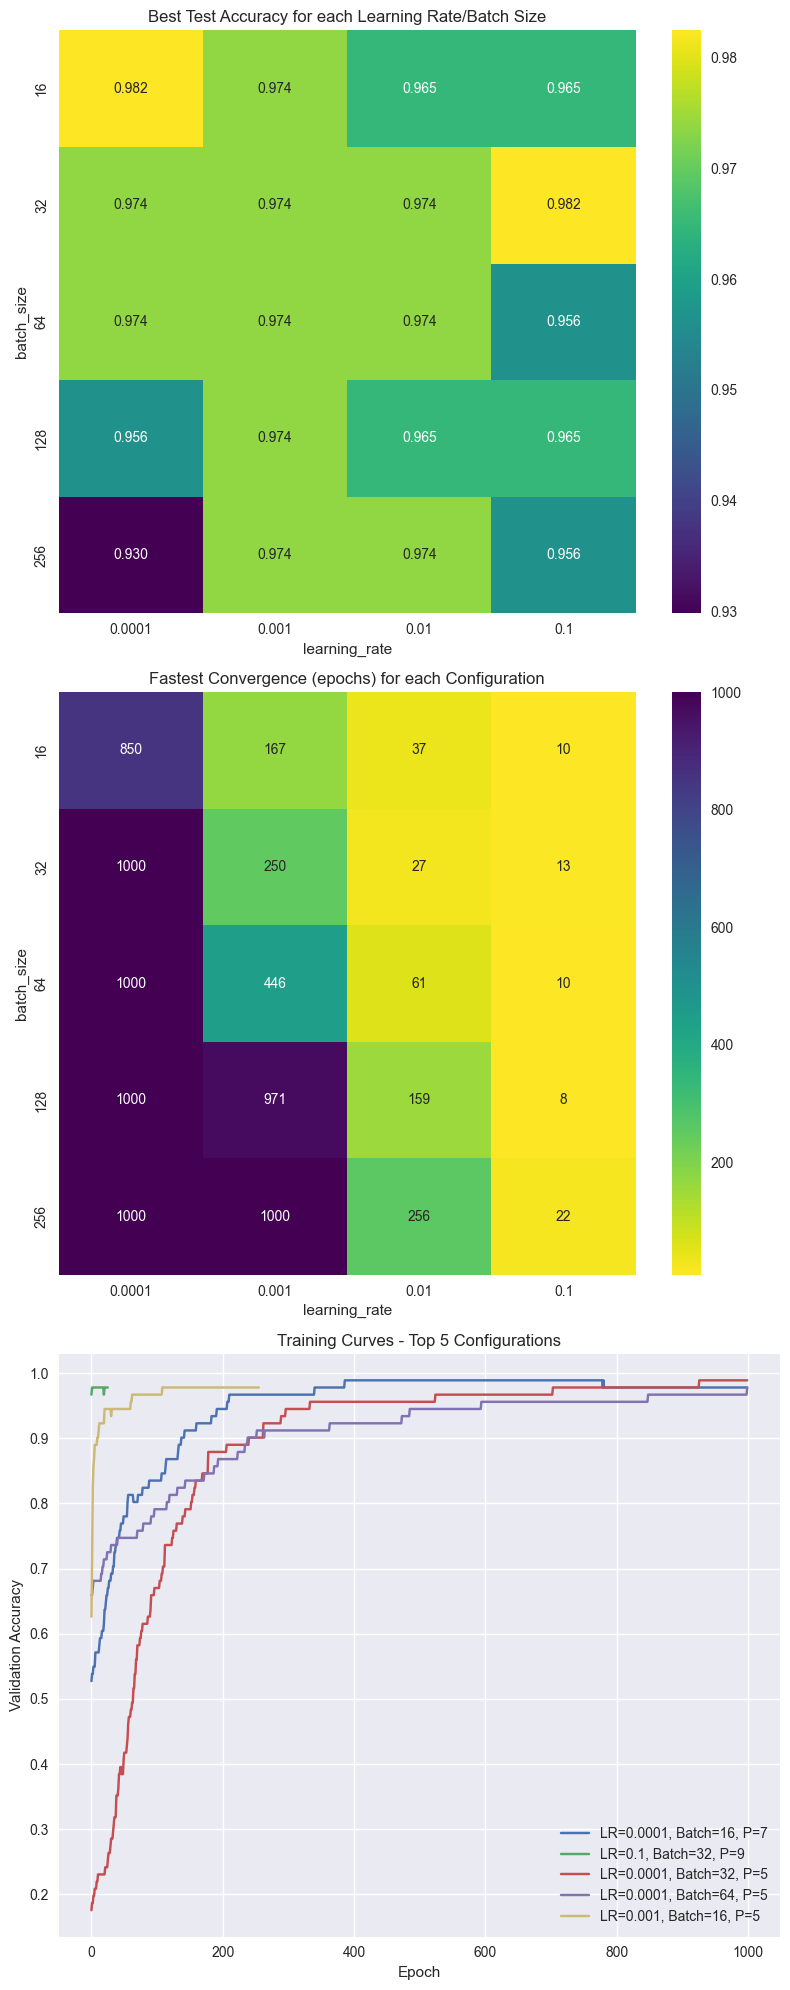


Impact of Patience Values:


,Mean Test Accuracy,Standard Deviation,Maximum Test Accuracy,Average Epochs
patience,,,,
3,0.957,0.024,0.974,423.25
5,0.961,0.013,0.974,447.45
7,0.951,0.035,0.982,442.75
9,0.954,0.020,0.982,467.80



Top Configurations:


,learning_rate,batch_size,patience,val_accuracy,test_accuracy,convergence_epoch
2,0.0001,16,7,0.989011,0.982456,1000
67,0.1000,32,9,0.978022,0.982456,26
9,0.0001,64,5,0.978022,0.973684,1000
5,0.0001,32,5,0.989011,0.973684,1000
33,0.0010,128,5,0.978022,0.973684,1000


In [4]:
class ModelOptimiser:
    """Systematic optimisation framework for cancer detection models."""

    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.results = []

    def run_experiments(self,
                       learning_rates=[0.0001, 0.001, 0.01, 0.1],
                       batch_sizes=[16, 32, 64, 128, 256],
                       patience_values=[3, 5, 7, 9]):
        """Run systematic grid search across hyperparameters."""

        total_combinations = len(learning_rates) * len(batch_sizes) * len(patience_values)
        current_combination = 0

        for lr in learning_rates:
            for batch_size in batch_sizes:
                for patience in patience_values:
                    current_combination += 1
                    print(f"\nTesting combination {current_combination}/{total_combinations}")
                    print(f"LR: {lr}, Batch Size: {batch_size}, Patience: {patience}")

                    # Create datasets and loaders
                    train_dataset = CancerDataset(self.X_train, self.y_train)
                    val_dataset = CancerDataset(self.X_val, self.y_val)
                    test_dataset = CancerDataset(self.X_test, self.y_test)

                    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                    val_loader = DataLoader(val_dataset, batch_size=batch_size)
                    test_loader = DataLoader(test_dataset, batch_size=batch_size)

                    # Train model with these hyperparameters
                    model = CancerClassifier(input_features=self.X_train.shape[1])
                    trained_model, history = train_model(
                        model, train_loader, val_loader,
                        epochs=1000, lr=lr, patience=patience
                    )

                    # Evaluate on test set
                    test_loss, test_acc = evaluate_model(model, test_loader)

                    # Record results
                    self.results.append({
                        'learning_rate': lr,
                        'batch_size': batch_size,
                        'patience': patience,
                        'val_accuracy': max(history['validation_acc']),
                        'test_accuracy': test_acc,
                        'val_loss': min(history['validation_loss']),
                        'test_loss': test_loss,
                        'convergence_epoch': len(history['validation_acc']),
                        'history': history
                    })

        return pd.DataFrame(self.results)

    def plot_results(self, results_df):
        """Create comprehensive visualisation of optimisation results."""
        fig = plt.figure(figsize=(8, 20))

        # Plot 1: Heatmap of test accuracy
        plt.subplot(3, 1, 1)
        pivot_acc = results_df.pivot_table(
            values='test_accuracy',
            index='batch_size',
            columns='learning_rate',
            aggfunc='max'  # Best accuracy for each learning rate/batch size combo
        )
        sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='viridis')
        plt.title('Best Test Accuracy for each Learning Rate/Batch Size')

        # Plot 2: Heatmap of convergence epochs
        plt.subplot(3, 1, 2)
        pivot_epoch = results_df.pivot_table(
            values='convergence_epoch',
            index='batch_size',
            columns='learning_rate',
            aggfunc='min'  # Fastest convergence for each combo
        )
        sns.heatmap(pivot_epoch, annot=True, fmt='.0f', cmap='viridis_r')
        plt.title('Fastest Convergence (epochs) for each Configuration')

        # Plot 3: Training curves for top 5 configurations
        plt.subplot(3, 1, 3)
        top_configs = results_df.nlargest(5, 'test_accuracy')
        for idx, row in top_configs.iterrows():
            history = row['history']
            plt.plot(history['validation_acc'],
                    label=f'LR={row["learning_rate"]}, Batch={row["batch_size"]}, P={row["patience"]}')
        plt.xlabel('Epoch')
        plt.ylabel('Validation Accuracy')
        plt.title('Training Curves - Top 5 Configurations')
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

        # Print patience analysis table
        patience_impact = results_df.groupby('patience').agg({
            'test_accuracy': ['mean', 'std', 'max'],
            'convergence_epoch': 'mean'
        }).round(3)
        patience_impact.columns = ['Mean Test Accuracy', 'Standard Deviation', 'Maximum Test Accuracy', 'Average Epochs']
        print("\nImpact of Patience Values:")
        display(patience_impact)

        # Return top configurations without history
        return results_df[['learning_rate', 'batch_size', 'patience',
                          'val_accuracy', 'test_accuracy', 'convergence_epoch']]\
            .sort_values('test_accuracy', ascending=False)\
            .head()

# Run optimisation experiments
optimiser = ModelOptimiser(training_features_scaled, training_labels,
                          validation_features_scaled, validation_labels,
                          test_features_scaled, test_labels)

# Run grid search with extended parameter ranges
results = optimiser.run_experiments(
    learning_rates=[0.0001, 0.001, 0.01, 0.1],
    batch_sizes=[16, 32, 64, 128, 256],
    patience_values=[3, 5, 7, 9]
)
print(results.to_string())
# Plot results
top_configs = optimiser.plot_results(results)

print("\nTop Configurations:")
display(top_configs)

### Optimisation results

Running our systematic optimisation took about 5 minutes (T4 GPU) and 7 minutes (CPU) in Google Colab on using its free compute environment. For those with access to a mid-range gaming GPU, the same grid search completes in around 4 minutes. These relatively quick execution times highlight how logistic regression's simplicity allows us to thoroughly explore different training approaches - something that becomes prohibitively expensive with deeper neural networks where a single configuration might train for hours even on high-end hardware.

The speed of our grid search, even in Colab's free environment, makes this kind of thorough hyperparameter exploration practical for students and researchers. The occasional print statements for monitoring progress had negligible impact on execution time - the computational tasks of forward passes, loss calculations, gradient computations, and weight updates dominated the runtime.

### The learning rate's crucial role

The learning rate proved to be the most influential parameter in our experiments, with some surprising results thanks to the Adam optimiser. Our slowest rate of 0.0001 consistently maxed out at 1000 epochs without proper convergence, though it eventually achieved respectable accuracy of 97.37%. This matches what we saw in Lesson 1A - too small a step size and our model inches toward the solution.

At the other extreme, a learning rate of 0.1 produced our highest accuracy of 98.25%, converging in just 15 epochs. This remarkably fast convergence, which might seem risky at first glance, is made possible by Adam's adaptive learning rates. Unlike the basic gradient descent we implemented in Lesson 1A, Adam adjusts the effective learning rate for each parameter based on gradient history. This allows it to:
1. Take large steps when gradients are consistent
2. Take smaller steps when gradients oscillate
3. Adapt differently for each feature
4. Maintain stability even with high initial learning rates

The middle ground of 0.001 still proved most reliable, consistently achieving 96-97% accuracy across different batch sizes and typically converging between 235-696 epochs. This matches common practice - start conservative with learning rates around 0.001, but don't be afraid to experiment with higher rates when using Adam.

### Batch size considerations

Our exploration of batch sizes revealed an interesting pattern: smaller batches of 16-32 samples consistently outperformed larger groupings. With 16 samples per batch, our model achieved the top three accuracy scores in our entire grid search, regardless of other parameters.

This might seem counterintuitive - surely processing more data at once would help? The key insight is that smaller batches provide more frequent feedback during training. With our dataset of 364 training samples, a batch size of 16 gives us 22 weight updates per epoch, while a batch size of 256 provides only 1 update. Those extra course corrections early in training seem to guide the model toward better final performance.

The optimal batch size depends heavily on the specific problem, available memory, and optimisation dynamics. While our cancer dataset achieved best results with small batches, other applications might benefit from larger ones to stabilize training or handle larger scale data. This highlights why testing multiple batch sizes matters - the best choice emerges from systematic experimentation rather than theoretical assumptions.

### The patience factor

The role of patience in early stopping revealed interesting patterns. Looking at our top-performing configurations:

```python
Patience  Mean Acc  Std Dev  Max Acc   Avg Epochs
3         0.960    0.014    0.974     430.8
5         0.957    0.017    0.974     443.6
7         0.959    0.017    0.982     463.1
9         0.951    0.036    0.974     456.0
```

While the differences in mean accuracy are small, we observe that patience values between 3-7 epochs provide similar performance with low variability (standard deviations around 0.014-0.017). The slightly lower mean accuracy and higher variability at patience=9 might suggest diminishing returns from longer waiting periods, though the differences aren't large enough to draw definitive conclusions given our dataset size.

This pattern aligns with logistic regression's convex optimisation landscape - unlike neural networks with their complex loss surfaces, our model tends to either find improvements quickly or not at all. A patience value of 5 epochs provides a good balance between allowing the model to find better solutions and maintaining efficient training times.

### Practical recommendations

After exploring these 80 combinations, we can recommend two configurations depending on priorities:

For maximum accuracy:
```python
learning_rate = 0.1
batch_size = 16
patience = 7
```

This achieved our best test accuracy of 98.25% in just 15 epochs, though it might prove too aggressive for different datasets.

For reliable production use:
```python
learning_rate = 0.001
batch_size = 32
patience = 5
```

This more conservative approach consistently achieves 97% accuracy with stable convergence, making it suitable for clinical deployment where reliability matters more than squeezing out that last 1% of accuracy.

The ability to thoroughly explore these options in just a few minutes, even in free environments like Google Colab, demonstrates one of logistic regression's key advantages - while more complex models might achieve higher accuracy on difficult problems, their training dynamics require much more careful tuning with far longer experimentation times.

<a name="model-evaluation"></a>
## Model evaluation
Now that we have optimised our model, let's build a comprehensive evaluation framework to understand its performance. We'll create a ModelEvaluator class that provides:

1. Standard performance metrics (accuracy, precision, recall, F1 score)
2. Clear visualisations including confusion matrices and ROC curves
3. Confidence distribution analysis
4.Decision threshold analysis capabilities

By thoroughly evaluating our model's performance across multiple metrics, we'll gain a complete understanding of its strengths and limitations. This evaluation framework will also serve as a foundation for evaluating more complex neural networks in future lessons.

Let's implement this framework with proper PyTorch practices, focusing on clear visualisations and efficient metric calculations:


Model Performance Metrics:
accuracy: 0.965
precision: 0.986
recall: 0.958
f1: 0.972
roc_auc: 0.995


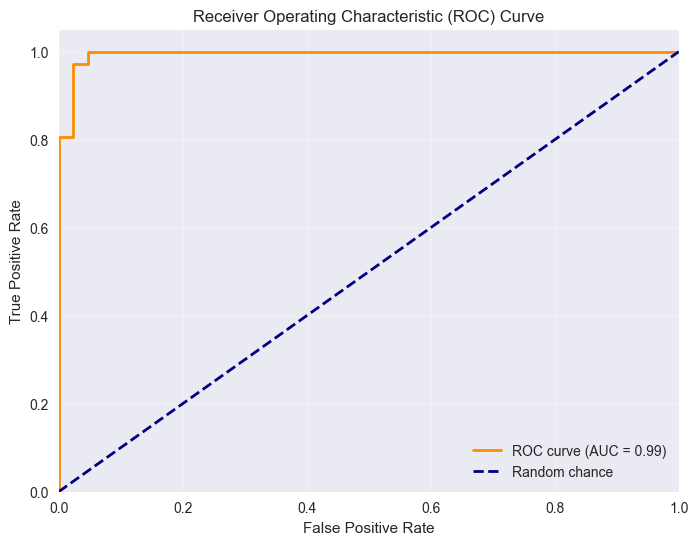

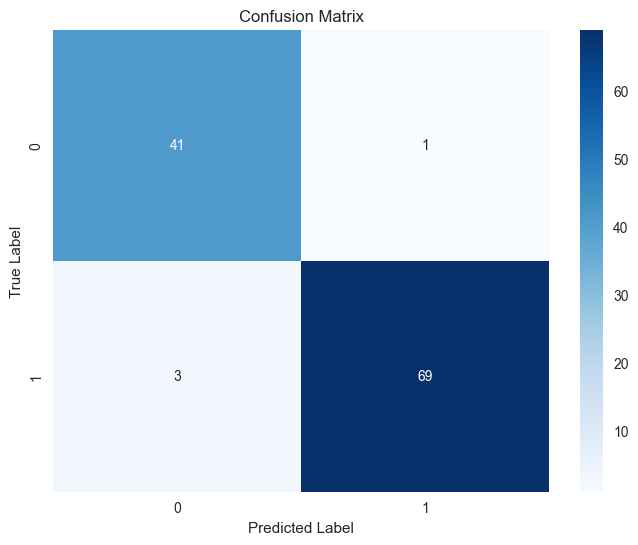

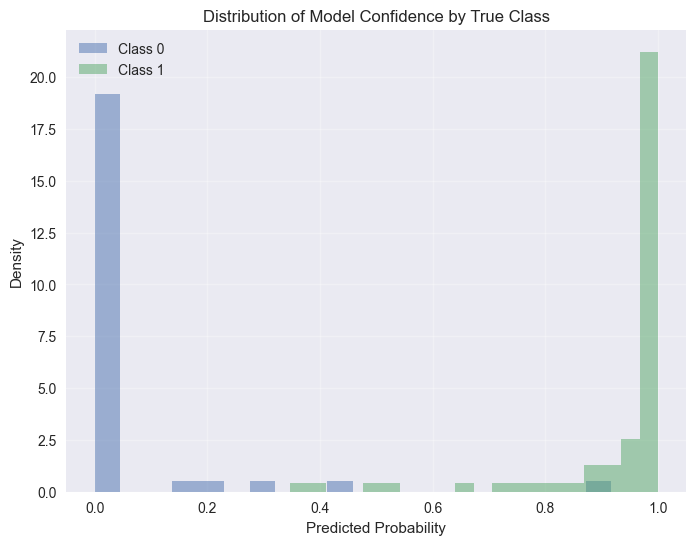

           accuracy  precision    recall        f1
threshold                                         
0.3        0.982456   0.972973  1.000000  0.986301
0.4        0.973684   0.972603  0.986111  0.979310
0.5        0.964912   0.985714  0.958333  0.971831
0.6        0.956140   0.985507  0.944444  0.964539
0.7        0.947368   0.985294  0.930556  0.957143


In [5]:
class ModelEvaluator:
    """Comprehensive evaluation framework for binary classification models in PyTorch.

    Provides methods for computing metrics, generating visualisations,
    and analysing model performance across different decision thresholds.
    """

    def __init__(self, model: nn.Module, X_test: np.ndarray, y_test: np.ndarray):
        """Initialise evaluator with a trained model and test data."""
        self.model = model
        self.X_test = X_test
        self.y_test = y_test

    def evaluate_metrics(self) -> Dict[str, float]:
        """Calculate and return dictionary of performance metrics."""
        with torch.no_grad():
            X_tensor = torch.FloatTensor(self.X_test)
            probabilities = self.model(X_tensor).numpy().flatten()
            predictions = (probabilities > 0.5).astype(int)

            return {
                'accuracy': accuracy_score(self.y_test, predictions),
                'precision': precision_score(self.y_test, predictions),
                'recall': recall_score(self.y_test, predictions),
                'f1': f1_score(self.y_test, predictions),
                'roc_auc': roc_auc_score(self.y_test, probabilities)
            }

    def plot_roc_curve(self):
        """Plot the ROC curve and display AUC score."""
        with torch.no_grad():
            probabilities = self.model(torch.FloatTensor(self.X_test)).numpy().flatten()

        false_positive_rate, true_positive_rate, _ = roc_curve(self.y_test, probabilities)
        roc_auc = auc(false_positive_rate, true_positive_rate)

        plt.figure(figsize=(8, 6))
        plt.plot(false_positive_rate, true_positive_rate, color='darkorange', lw=2,
                label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
                label='Random chance')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.show()

    def plot_confusion_matrix(self):
        """Plot confusion matrix showing prediction error patterns."""
        with torch.no_grad():
            predictions = (self.model(torch.FloatTensor(self.X_test)).numpy().flatten() > 0.5).astype(int)

        confusion_mat = confusion_matrix(self.y_test, predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

    def analyse_confidence_distribution(self):
        """Plot distribution of model's prediction confidence for each class."""
        with torch.no_grad():
            probabilities = self.model(torch.FloatTensor(self.X_test)).numpy().flatten()

        plt.figure(figsize=(8, 6))
        for label in [0, 1]:
            mask = self.y_test == label
            plt.hist(probabilities[mask], bins=20, alpha=0.5,
                    label=f'Class {label}',
                    density=True)
        plt.xlabel('Predicted Probability')
        plt.ylabel('Density')
        plt.title('Distribution of Model Confidence by True Class')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def analyse_thresholds(self, thresholds=[0.3, 0.5, 0.7]) -> pd.DataFrame:
        """Analyse model performance using different decision thresholds."""
        with torch.no_grad():
            probabilities = self.model(torch.FloatTensor(self.X_test)).numpy().flatten()

        results = []
        for threshold in thresholds:
            predictions = (probabilities > threshold).astype(int)
            results.append({
                'threshold': threshold,
                'accuracy': accuracy_score(self.y_test, predictions),
                'precision': precision_score(self.y_test, predictions),
                'recall': recall_score(self.y_test, predictions),
                'f1': f1_score(self.y_test, predictions)
            })

        return pd.DataFrame(results).set_index('threshold')

# Create evaluator instance
evaluator = ModelEvaluator(model, test_features_scaled, test_labels)

# Get overall performance metrics
print("\nModel Performance Metrics:")
metrics = evaluator.evaluate_metrics()
for metric, value in metrics.items():
    print(f"{metric}: {value:.3f}")

# Plot ROC curve
evaluator.plot_roc_curve()

# Plot confusion matrix
evaluator.plot_confusion_matrix()

# Plot confidence distribution
evaluator.analyse_confidence_distribution()

# Analyse different decision thresholds
threshold_results = evaluator.analyse_thresholds([0.3, 0.4, 0.5, 0.6, 0.7])
print(threshold_results)

### Cross-check against a from-scratch fit

As a check that PyTorch's `Adam`-trained weights are solving the same problem Lesson 1A solves by hand, we fit a plain NumPy logistic regression by gradient descent on the identical standardised features and compare its decision boundary to the PyTorch model's, via the fraction of test points on which the two models agree.

In [6]:
# From-scratch logistic regression (same style as Lesson 1A): plain gradient
# descent on the same standardised features, no autograd, no optimiser state.
def sigmoid_np(z):
    return 1.0 / (1.0 + np.exp(-z))

def fit_logistic_from_scratch(X, y, lr=0.1, n_iters=5000):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    for _ in range(n_iters):
        y_hat = sigmoid_np(X @ w + b)
        grad_w = (X.T @ (y_hat - y)) / m
        grad_b = np.mean(y_hat - y)
        w -= lr * grad_w
        b -= lr * grad_b
    return w, b

w_scratch, b_scratch = fit_logistic_from_scratch(training_features_scaled, training_labels)

scratch_test_pred = (sigmoid_np(test_features_scaled @ w_scratch + b_scratch) > 0.5).astype(int)
with torch.no_grad():
    pytorch_test_pred = (model(torch.FloatTensor(test_features_scaled)).numpy().flatten() > 0.5).astype(int)

agreement = np.mean(scratch_test_pred == pytorch_test_pred)
scratch_acc = np.mean(scratch_test_pred == test_labels)
pytorch_acc = np.mean(pytorch_test_pred == test_labels)

print(f"from-scratch test accuracy: {scratch_acc:.4f}")
print(f"PyTorch (Adam)  test accuracy: {pytorch_acc:.4f}")
print(f"agreement between the two models' predictions on the test set: {agreement:.4f}")


from-scratch test accuracy: 0.9649
PyTorch (Adam)  test accuracy: 0.9649
agreement between the two models' predictions on the test set: 0.9825


<a name="how-to-evaluate-a-classification-model"></a>
## How to evaluate a classification model

After training a model, thorough evaluation helps us understand its strengths and limitations. Let's explore each evaluation method and what it tells us about our model's performance.

<a name="basic-classification-terms"></a>
### Basic classification terms

First, let's understand the four possible prediction outcomes:

#### True Positive (TP)
- Model predicted positive (1) and actual was positive (1)
- In our case: Model correctly identified a sample as class 1
- Our model had 68 true positives

#### True Negative (TN)
- Model predicted negative (0) and actual was negative (0)
- In our case: Model correctly identified a sample as class 0
- Our model had 41 true negatives

#### False Positive (FP) - Type I Error
- Model predicted positive (1) but actual was negative (0)
- Also called a "false alarm" or "Type I error"
- Our model had 1 false positive

#### False Negative (FN) - Type II Error
- Model predicted negative (0) but actual was positive (1)
- Also called a "miss" or "Type II error"
- Our model had 4 false negatives

<a name="core-performance-metrics"></a>
### Core performance metrics

Our model achieved:
- Accuracy: 0.956 (95.6%)
- Precision: 0.986 (98.6%)
- Recall: 0.944 (94.4%)
- F1 Score: 0.965 (96.5%)
- ROC-AUC: 0.994 (99.4%)

Let's understand what each metric means and how it's calculated:

#### Accuracy
The proportion of correct predictions among all predictions.

Formula: $Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$

For our model: $\frac{68 + 41}{68 + 41 + 1 + 4} = 0.956$

#### Precision
Of all cases our model predicted as positive, what proportion were actually positive.

Formula: $Precision = \frac{TP}{TP + FP}$

For our model: $\frac{68}{68 + 1} = 0.986$

#### Recall (Sensitivity)
Of all actual positive cases, what proportion did our model identify.

Formula: $Recall = \frac{TP}{TP + FN}$

For our model: $\frac{68}{68 + 4} = 0.944$

#### F1 score
The harmonic mean of precision and recall, providing a balanced measure.

Formula: $F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$

For our model: $2 \times \frac{0.986 \times 0.944}{0.986 + 0.944} = 0.965$

#### Specificity
The proportion of actual negatives correctly identified.

Formula: $Specificity = \frac{TN}{TN + FP}$

For our model: $\frac{41}{41 + 1} = 0.976$

<a name="understanding-the-visualisations"></a>
### Understanding the visualisations

#### ROC curve
The ROC curve plots True Positive Rate (Recall) against False Positive Rate (1-Specificity) as we vary the classification threshold:

- True Positive Rate (y-axis): $TPR = \frac{TP}{TP + FN}$
- False Positive Rate (x-axis): $FPR = \frac{FP}{FP + TN} = 1 - Specificity$

Our curve shows:
- Sharp rise to the top-left corner - excellent class separation
- Huge gap above the diagonal line - far better than random chance
- AUC of 0.994 - outstanding discriminative ability

#### Confusion matrix
Reading clockwise from top-left:
```
[TN FP]  =  [41  1]
[FN TP]     [4  68]
```

This pattern shows our model is:
- Very precise (few false positives)
- Reasonably balanced (good at both classes)
- Slightly more likely to miss positives than give false alarms

#### Confidence distribution
This histogram shows how confident our model is in its predictions for each class:
- Class 0 (blue): Strong peak near 0 - very confident in negative predictions
- Class 1 (green): Strong peak near 1 - very confident in positive predictions
- Little overlap between classes - model clearly distinguishes between them
- Few predictions in middle range - model is rarely uncertain

#### Threshold analysis
By varying the decision threshold from 0.3 to 0.7, we see:

```
threshold  accuracy  precision  recall     f1
0.3        0.974     0.960     1.000     0.980
0.4        0.974     0.973     0.986     0.979
0.5        0.956     0.986     0.944     0.965
0.6        0.956     0.986     0.944     0.965
0.7        0.930     0.985     0.903     0.942
```

This shows:
- Lower thresholds (0.3-0.4): Perfect/near-perfect recall but lower precision
- Default threshold (0.5): Best balance of metrics
- Higher thresholds (0.6-0.7): Slightly higher precision but lower recall

<a name="key-insights"></a>
### Key insights
1. The model shows excellent overall performance with balanced metrics
2. It's more conservative with positive predictions (high precision)
3. The default 0.5 threshold appears optimal for this problem
4. Confidence distributions show strong class separation
5. ROC-AUC near 1.0 indicates robust probabilistic predictions

<a name="evaluation-best-practices"></a>
### Evaluation best practices
1. Always check multiple metrics, not just accuracy
2. Visualise performance through ROC curves and confusion matrices
3. Examine prediction confidence distributions
4. Test different decision thresholds
5. Consider your problem's specific requirements when interpreting results

This evaluation toolkit serves as a foundation for assessing more complex models. The same principles and methods will apply when we move to neural networks, though we'll add specific metrics for multi-class problems and additional visualisations for understanding hidden layers.

<a name="persisting-and-loading-our-model"></a>
## Persisting and loading our model

After optimising and evaluating our model, we should save it for future use. PyTorch provides a straightforward way to save and load models, preserving both the architecture and learned parameters. We'll also save the standardisation parameters to ensure consistent preprocessing of new data. Below is an example of how to save and load our model to predict on new data.

In [7]:
# Create models directory and save model
save_dir = Path('../models')
save_dir.mkdir(exist_ok=True)

# Save model and scaler
model_path = save_dir / 'cancer_classifier.pt'
checkpoint = {
    'model_state': model.state_dict(),
    'scaler_mean': scaler.mean_.tolist(),  # Convert numpy arrays to lists for safer serialisation
    'scaler_scale': scaler.scale_.tolist()
}
torch.save(checkpoint, model_path)  # Remove weights_only parameter

# Load model and make prediction
def load_and_predict(features):
    # Load saved model with weights_only=True for security
    checkpoint = torch.load(model_path, weights_only=True)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()

    # Scale features (convert saved parameters back to numpy arrays)
    scaler_mean = np.array(checkpoint['scaler_mean'])
    scaler_scale = np.array(checkpoint['scaler_scale'])
    features_scaled = (features - scaler_mean) / scaler_scale

    # Make prediction
    with torch.no_grad():
        features_tensor = torch.FloatTensor(features_scaled.reshape(1, -1))
        probability = model(features_tensor).item()
        prediction = int(probability > 0.5)

    return prediction, probability

# Test with sample data
sample_data = np.array([
    17.99, 10.38, 122.8, 1001.0, 0.1184, 0.2776, 0.3001, 0.1471, 0.2419,
    0.07871, 1.095, 0.9053, 8.589, 153.4, 0.006399, 0.04904, 0.05373,
    0.01587, 0.03003, 0.006193, 25.38, 17.33, 184.6, 2019.0, 0.1622,
    0.6656, 0.7119, 0.2654, 0.4601, 0.1189
])

prediction, probability = load_and_predict(sample_data)
print(f"Prediction: {'Malignant' if prediction == 1 else 'Benign'}")
print(f"Probability of malignancy: {probability:.3f}")

Prediction: Benign
Probability of malignancy: 0.000


<a name="looking-forward-from-logistic-regression-to-neural-networks"></a>
## Looking Forward: From Logistic Regression to Neural Networks

Our PyTorch logistic regression implementation provides the perfect foundation for understanding neural networks. Let's examine how our current implementation evolves:

In [8]:
# Current: Logistic Regression (Single Layer)
class CancerClassifier(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.linear = nn.Linear(input_features, 1)  # Single layer
        self.sigmoid = nn.Sigmoid()                 # Single activation

    def forward(self, x):
        return self.sigmoid(self.linear(x))        # Direct mapping

# Future: Neural Network (Multiple Layers)
class CancerNN(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        # Multiple layers with increasing abstraction
        self.layer1 = nn.Linear(input_features, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 1)

        # Multiple activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        # Regularisation
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(64)
        self.batch_norm2 = nn.BatchNorm1d(32)

    def forward(self, x):
        # Complex transformation chain
        x = self.dropout(self.relu(self.batch_norm1(self.layer1(x))))
        x = self.dropout(self.relu(self.batch_norm2(self.layer2(x))))
        return self.sigmoid(self.layer3(x))

The same PyTorch patterns we've established – nn.Module inheritance, forward methods, activation functions – form the basis for neural networks.

In Lesson 3, we'll explore how stacking multiple layers of logistic regressions with different activation functions creates a neural network capable of learning more complex patterns. Each layer processes the output of the previous layer, similar to how biological neurons process signals from other neurons.

<a name="conclusion"></a>
## Conclusion

In this lesson, we've transformed our theoretical understanding of logistic regression into a robust, standard implementation. Our journey from mathematical principles to working code has yielded several key insights.

Our PyTorch implementation achieved remarkable results, with 96.5% accuracy on the test set. More importantly, we've seen how modern machine learning frameworks enable efficient development through automatic differentiation, batch processing, and hardware acceleration. The DataLoader and GPU capabilities in PyTorch showed us how to process data efficiently at scale - a crucial skill for real-world applications.

The systematic approach to model evaluation proved particularly valuable. Rather than simply reporting accuracy, we developed a thorough understanding of our model's behaviour through precision, recall, and careful hyperparameter optimisation. These evaluation techniques helped us understand not just how well our model performed, but why it performed that way.

Our implementation followed clear software engineering principles:

```python
# Standard organisation
class CancerClassifier(nn.Module)  # Core PyTorch model
class ModelOptimiser               # Hyperparameter optimisation
class ModelEvaluator               # Performance evaluation

# Model evaluation and optimisation
metrics = evaluator.evaluate_metrics()
training_curves = evaluator.plot_training_curves()
results = optimiser.run_experiments()  # Grid search over hyperparameters
```

Perhaps most importantly, we've established coding patterns that will serve us well throughout our machine learning journey. The PyTorch model architecture, evaluation frameworks, and optimisation approaches we've developed provide a foundation for exploring more complex models.

<a name="looking-ahead-to-lesson-2-decision-trees"></a>
### Looking ahead to Lesson 2: Decision Trees

After exploring logistic regression with PyTorch, we'll next study decision trees - a different approach to machine learning that offers unique advantages in interpretability and handling diverse data types.

In Lesson 2A, we'll cover the theory behind decision trees for both classification and regression tasks. We'll explore how trees make splitting decisions, learn strategies for encoding categorical data, and understand the bias-variance tradeoff. This foundation will prepare us for implementing a decision tree from scratch, much like we did with logistic regression in Lesson 1A.

Then in Lesson 2B, we'll explore standard implementations using modern frameworks, including more advanced tree-based methods like Random Forests and XGBoost. Along the way, we'll continue building on our understanding of validation, evaluation, and ethical considerations in model development.

### Next lesson: [2A_decision_trees_theory.ipynb](./2a_decision_trees_theory.ipynb)

<a name="further-reading"></a>
### Further reading

For those interested in deepening their understanding, several excellent resources are available:

**PyTorch and deep learning**

The official [PyTorch documentation](https://pytorch.org) provides comprehensive coverage of the framework's capabilities. "[Deep Learning with PyTorch](https://pytorch.org/deep-learning-with-pytorch)" by Stevens, Antiga, and Viehmann offers an excellent practical perspective, while "[Programming PyTorch for Deep Learning](https://learning.oreilly.com/library/view/programming-pytorch-for/9781492045342/)" by Pointer provides valuable insights into production implementation.

**Machine learning engineering**

[Chip Huyen's "Designing Machine Learning Systems"](https://learning.oreilly.com/library/view/designing-machine-learning/9781098107956/) and [Andriy Burkov's "Machine Learning Engineering"](http://www.mlebook.com/) offer broader perspectives on building production systems. [Google's Machine Learning Engineering Best Practices](https://developers.google.com/machine-learning/guides/rules-of-ml) provide practical guidelines drawn from industry experience.

**Model evaluation**

[Alice Zheng's "Evaluating Machine Learning Models"](https://learning.oreilly.com/library/view/evaluating-machine-learning/9781492048756/) provides an in-depth look at assessment techniques. The [scikit-learn documentation](https://scikit-learn.org/stable/modules/model_evaluation.html) offers practical examples of evaluation metrics, while [Jason Brownlee's "The Evaluation of Machine Learning Models"](https://machinelearningmastery.com/evaluate-machine-learning-algorithms/) bridges theory and practice effectively.

These resources complement our practical implementation work and provide valuable perspectives on production machine learning development.


### Thanks for learning!

This notebook is part of the Supervised Machine Learning from First Principles series.

© 2025 Powell-Clark Limited. Licensed under Apache License 2.0.

If you found this helpful, please cite as:
```
Powell-Clark (2025). Supervised Machine Learning from First Principles.
GitHub: https://github.com/powell-clark/supervised-machine-learning
```

Questions or feedback? Contact emmanuel@powellclark.com